In [1]:
from dotenv import load_dotenv
from pathlib import Path
import sys
import os

# Walk up until we find the project root (folder with the .env)
current_path = Path().resolve()
for parent in [current_path] + list(current_path.parents):
    if (parent / ".env").exists():
        load_dotenv(parent / ".env")
        project_root = os.getenv("PROJECT_ROOT")
        print(project_root)
        sys.path.append(project_root)     
        break


%load_ext autoreload
%autoreload 2

C:\Users\Admin\Desktop\Emmanuel\beluga-call-pipeline\


Failed to read module file 'C:\Users\Admin\AppData\Roaming\uv\python\cpython-3.12.8-windows-x86_64-none\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Admin\Desktop\Emmanuel\beluga-call-pipeline\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\Desktop\Emmanuel\beluga-call-pipeline\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\AppData\Roaming\uv\python\cpython-3.12.8-windows-x86_64-none\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen imp

In [35]:
import pandas as pd
from pathlib import Path

dir = "../new_results/optimization/mobile_net_12_layers"

# Loop through all folds and collect DataFrames
all_predictions = []
for fold_num in range(5):
    fold_path = Path(dir) / f"fold_{fold_num}" / "test_predictions.csv"
    fold_df = pd.read_csv(fold_path)
    all_predictions.append(fold_df)

# Merge all predictions into one DataFrame
test_predictions_df = pd.concat(all_predictions, ignore_index=True)
test_predictions_df

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold
0,BSM_20170724_11080300.pt,BSM,0.0,0.0,5.232561e-09,0.0,0.0,3.602791e-09,0.0,0.0,1.564860e-11,0.0,0.0,6.546491e-15,0
1,BSM_20170724_11370200.pt,BSM,0.0,0.0,3.873535e-08,0.0,0.0,9.329182e-10,0.0,0.0,1.500955e-10,0.0,0.0,5.086012e-10,0
2,BSM_20170724_11370300.pt,BSM,0.0,0.0,3.557386e-11,0.0,0.0,1.807081e-11,0.0,0.0,8.282940e-09,0.0,0.0,1.503849e-06,0
3,BSM_20170724_12500300.pt,BSM,0.0,0.0,1.861418e-10,0.0,0.0,1.230424e-09,0.0,0.0,9.414891e-11,0.0,0.0,6.851429e-08,0
4,BSM_20170724_13132859.pt,BSM,0.0,0.0,6.516511e-05,0.0,0.0,2.212144e-08,0.0,0.0,3.324768e-04,0.0,1.0,9.999827e-01,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16830,RDL_20200901_19191674.pt,RDL,0.0,0.0,1.202951e-02,0.0,0.0,1.493103e-10,0.0,0.0,2.377552e-08,0.0,0.0,1.776518e-08,4
16831,RDL_20200901_19192512.pt,RDL,0.0,0.0,9.348188e-04,0.0,0.0,7.628451e-12,0.0,0.0,2.214313e-09,0.0,0.0,8.463153e-10,4
16832,RDL_20200906_14553196.pt,RDL,0.0,0.0,1.637192e-07,0.0,0.0,6.448618e-13,0.0,0.0,3.730531e-09,0.0,0.0,2.633798e-09,4
16833,RDL_20200906_14553296.pt,RDL,0.0,0.0,5.529305e-11,0.0,0.0,1.831266e-14,0.0,0.0,4.258700e-10,0.0,0.0,1.828280e-09,4


In [36]:
import pandas as pd
labels_df = pd.read_csv("../../data/Verified_Dataset/labels/labels_merged.csv")
labels_df["ClipFilenamePt"] = labels_df["clip_filename"].str.replace(".wav", ".pt", regex=False)

merged_df = test_predictions_df.merge(
    labels_df[["ClipFilenamePt", "Boat", "HydrophoneSensitivity", "labeling_effort", "original_filename", "labeled_snippet_filename", "Begin Time (s)"]],
    how="left",
    left_on="Filename",
    right_on="ClipFilenamePt"
)
test_predictions_df = merged_df.drop(columns=["ClipFilenamePt"])


C:\Users\Admin\AppData\Local\Temp\ipykernel_30956\2913277577.py:2: DtypeWarning: Columns (0: labeled_snippet_filename, 1: labeled_snippet_dir, 2: DETAILS, 3: boat_labeling_file, 4: annotator) have mixed types. Specify dtype option on import or set low_memory=False.
  labels_df = pd.read_csv("../../data/Verified_Dataset/labels/labels_merged.csv")


In [37]:
test_predictions_df["AnyCall_pred"] = test_predictions_df[["ECHO_pred", "HFPC_pred", "BBPC_pred", "Whistle_pred"]].any(axis=1)
test_predictions_df["AnyCall_true"] = test_predictions_df[["ECHO_true", "HFPC_true", "BBPC_true", "Whistle_true"]].any(axis=1)



In [38]:
pd.set_option('display.max_columns', None)
test_predictions_df.head(2)

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity,labeling_effort,original_filename,labeled_snippet_filename,Begin Time (s),AnyCall_pred,AnyCall_true
0,BSM_20170724_11080300.pt,BSM,0.0,0.0,5.232561e-09,0.0,0.0,3.602791e-09,0.0,0.0,1.564860e-11,0.0,0.0,6.546491e-15,0,NaN,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
1,BSM_20170724_11370200.pt,BSM,0.0,0.0,3.873535e-08,0.0,0.0,9.329182e-10,0.0,0.0,1.500955e-10,0.0,0.0,5.086012e-10,0,NaN,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False


In [39]:
from sklearn.metrics import multilabel_confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================================================================
# Configuration
# =============================================================================



# =============================================================================
# Core Metrics Functions
# =============================================================================
def get_multilabel_metrics(df, call_types, true_suffix="_true", pred_suffix="_pred"):
    """
    Get multilabel metrics and confusion matrices for a dataframe subset.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing predictions and ground truth
    call_types : list
        List of call type names
    subset_name : str
        Name for this subset (e.g., "Overall", "KAM_2020", "boat_passage")
        
    Returns:
    --------
    dict
        Dictionary containing metrics, confusion matrices, and metadata
    """
    if len(df) == 0:
        return None
        
    y_true = df[[f"{c}{true_suffix}" for c in call_types]].astype(int).values
    y_pred = df[[f"{c}{pred_suffix}" for c in call_types]].astype(int).values
    
    # Get classification report
    report = classification_report(
        y_true, 
        y_pred, 
        target_names=call_types, 
        output_dict=True, 
        zero_division=0
    )
    
    # Get confusion matrices
    mcm_array = multilabel_confusion_matrix(y_true, y_pred)
    mcm = {call_type: mcm_array[i] for i, call_type in enumerate(call_types)}
    # Calculate false alarm rate for each class
    # mcm shape: (n_classes, 2, 2) where each 2x2 matrix is [[TN, FP], [FN, TP]]
    false_alarm_rates = {}
    for call_type in call_types:
        tn, fp = mcm[call_type][0, 0], mcm[call_type][0, 1]
        # False Alarm Rate = FP / (FP + TN), avoid division by zero
        far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        report[call_type]["false_alarm_rate"] = far
    
    return {
        'report': report,
        'mcm': mcm,
        'false_alarm_rates': false_alarm_rates,
        'y_true': y_true,
        'y_pred': y_pred,
        'n_samples': len(df)
    }


def compute_metrics_by_grouping(df, call_types, group_by=None):
    """
    Compute metrics for overall data and by grouping variable.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing predictions and ground truth
    call_types : list
        List of call type names
    group_by : str or None
        Column name to group by (e.g., 'context', 'site', or None for overall only)
        
    Returns:
    --------
    tuple
        (metrics_overall, metrics_by_group) where metrics_by_group is a dict
    """
    # Overall metrics
    metrics_overall = get_multilabel_metrics(df, call_types)
    metrics_overall["name"] = "Overall"
    
    # Group-specific metrics
    metrics_by_group = {}
    if group_by and group_by in df.columns:
        unique_groups = df[group_by].unique()
        for group in unique_groups:
            df_group = df[df[group_by] == group]
            if len(df_group) > 0:
                metrics_by_group[group] = get_multilabel_metrics(df_group, call_types)
                metrics_by_group[group]["name"] = str(group)
    
    
    return metrics_overall, metrics_by_group


def create_summary_dataframe(metrics_overall, metrics_by_group, call_types, group_name="Group"):
    """
    Create a summary dataframe from computed metrics.
    
    Parameters:
    -----------
    metrics_overall : dict
        Overall metrics dictionary
    metrics_by_group : dict
        Dictionary of metrics by group
    call_types : list
        List of call type names
    group_name : str
        Name for the grouping column (e.g., "Context", "Site")
        
    Returns:
    --------
    pd.DataFrame
        Summary dataframe with metrics for all call types and groups
    """
    summary_data = []
    
    for call in call_types:
        # Overall
        if metrics_overall:
            summary_data.append({
                'Call Type': call,
                group_name: 'Overall',
                'Precision': metrics_overall['report'][call]['precision'],
                'Recall': metrics_overall['report'][call]['recall'],
                'F1-Score': metrics_overall['report'][call]['f1-score'],
                'False Alarm Rate': metrics_overall['report'][call]['false_alarm_rate'],
                'Support': int(metrics_overall['report'][call]['support'])
            })
        
        # By group
        for group_key, metrics in metrics_by_group.items():
            if metrics:
                summary_data.append({
                    'Call Type': call,
                    group_name: group_key,
                    'Precision': metrics['report'][call]['precision'],
                    'Recall': metrics['report'][call]['recall'],
                    'F1-Score': metrics['report'][call]['f1-score'],
                    'False Alarm Rate': metrics['report'][call]['false_alarm_rate'],
                    'Support': int(metrics['report'][call]['support'])
                })
    
    return pd.DataFrame(summary_data)


def create_average_metrics_dataframe(metrics_overall, metrics_by_group, group_name="Group"):
    """
    Create dataframe with averaged metrics across all call types.
    
    Parameters:
    -----------
    metrics_overall : dict
        Overall metrics dictionary
    metrics_by_group : dict
        Dictionary of metrics by group
    group_name : str
        Name for the grouping column
        
    Returns:
    --------
    pd.DataFrame
        Dataframe with macro/micro/samples averages
    """
    avg_metrics = []
    
    # Overall
    if metrics_overall:
        report = metrics_overall['report']
        avg_metrics.append({
            group_name: 'Overall',
            'Macro Avg Precision': report['macro avg']['precision'],
            'Macro Avg Recall': report['macro avg']['recall'],
            'Macro Avg F1': report['macro avg']['f1-score'],
            'Micro Avg F1': report['micro avg']['f1-score'],
            'False Alarm Rate': metrics_overall['false_alarm_rates'],
            'Samples Avg F1': report['samples avg']['f1-score'],
            'n_samples': metrics_overall['n_samples']
        })
    
    # By group
    for group_key, metrics in metrics_by_group.items():
        if metrics:
            report = metrics['report']
            avg_metrics.append({
                group_name: group_key,
                'Macro Avg Precision': report['macro avg']['precision'],
                'Macro Avg Recall': report['macro avg']['recall'],
                'Macro Avg F1': report['macro avg']['f1-score'],
                'Micro Avg F1': report['micro avg']['f1-score'],
                'False Alarm Rate': metrics['false_alarm_rates'],
                'Samples Avg F1': report['samples avg']['f1-score'],
                'n_samples': metrics['n_samples']
            })
    
    return pd.DataFrame(avg_metrics)


def plot_metrics_comparison(summary_df, group_name="Group", exclude_overall=True, figsize=(14, 10)):
    """
    Create bar plots comparing metrics across call types and groups.
    
    Parameters:
    -----------
    summary_df : pd.DataFrame
        Summary dataframe with metrics
    group_name : str
        Name of the grouping column
    exclude_overall : bool
        Whether to exclude 'Overall' from visualization
    figsize : tuple
        Figure size
        
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure
    """
    # Filter data
    plot_df = summary_df.copy()
    if exclude_overall:
        plot_df = plot_df[plot_df[group_name] != 'Overall']
    
    if len(plot_df) == 0:
        print("No data to plot after filtering")
        return None
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'Support']
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        
        # Pivot data for plotting
        pivot_data = plot_df.pivot(index='Call Type', columns=group_name, values=metric)
        
        pivot_data.plot(kind='bar', ax=ax, rot=0)
        ax.set_title(f'{metric} by Call Type and {group_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Call Type')
        ax.set_ylabel(metric)
        ax.legend(title=group_name, loc='best')
        ax.grid(axis='y', alpha=0.3)
        
        # Set y-limit only for percentage metrics
        if metric in ['Precision', 'Recall', 'F1-Score']:
            ax.set_ylim([0, 1.0])
    
    plt.tight_layout()
    return fig


def print_classification_report(metrics_overall, call_types):
    """Print formatted classification report."""
    if metrics_overall:
        print(f"\n{'='*80}")
        print("OVERALL CLASSIFICATION REPORT")
        print(f"{'='*80}\n")
        print(classification_report(
            metrics_overall['y_true'], 
            metrics_overall['y_pred'], 
            target_names=call_types, 
            zero_division=0
        ))


def print_summary_table(summary_df, group_name="Group"):
    """Print formatted summary table."""
    print(f"\n\n{'='*80}")
    print(f"SUMMARY TABLE: All Call Types by {group_name}")
    print(f"{'='*80}\n")
    print(summary_df.to_string(index=False))


def print_average_metrics(avg_df, group_name="Group"):
    """Print formatted average metrics table."""
    print(f"\n\n{'='*80}")
    print(f"AVERAGE METRICS ACROSS ALL CALL TYPES BY {group_name}")
    print(f"{'='*80}\n")
    print(avg_df.to_string(index=False))

In [40]:
test_predictions_df.groupby("Site")["AnyCall_true"].value_counts(dropna=False)

Site  AnyCall_true
BSM   False           7161
      True            1198
CAC   True            2159
      False           1608
KAM   True            2983
      False           1082
RDL   True             364
      False            280
Name: count, dtype: int64

In [41]:
# =============================================================================
# ANALYSIS BY CONTEXT
# =============================================================================
print("="*80)
print("ANALYSIS BY CONTEXT")
print("="*80)
call_types = ["ECHO", "BBPC", "HFPC", "Whistle"] + ["AnyCall"]


test_predictions_df["Boat"] = test_predictions_df["Boat"].fillna(0)

# Compute metrics
metrics_overall, metrics_by_context = compute_metrics_by_grouping(
    test_predictions_df, call_types, group_by='Boat'
)
# metrics_overall, metrics_by_context = compute_metrics_by_grouping(
#     test_predictions_df, ["AnyCall"], group_by='labeled_snippet_filename'
# )
# Print reports
print_classification_report(metrics_overall, call_types)


ANALYSIS BY CONTEXT

OVERALL CLASSIFICATION REPORT

              precision    recall  f1-score   support

        ECHO       0.95      0.90      0.93      5331
        BBPC       0.84      0.79      0.81       985
        HFPC       0.87      0.84      0.86       793
     Whistle       0.88      0.86      0.87      2917
     AnyCall       0.96      0.94      0.95      6704

   micro avg       0.93      0.90      0.92     16730
   macro avg       0.90      0.87      0.88     16730
weighted avg       0.93      0.90      0.92     16730
 samples avg       0.36      0.36      0.36     16730



In [42]:
metrics_by_context

{np.float64(0.0): {'report': {'ECHO': {'precision': 0.9483109483109483,
    'recall': 0.8866057838660578,
    'f1-score': 0.9164208456243854,
    'support': 2628.0,
    'false_alarm_rate': np.float64(0.014879906268306972)},
   'BBPC': {'precision': 0.8766404199475065,
    'recall': 0.8166259168704156,
    'f1-score': 0.8455696202531645,
    'support': 818.0,
    'false_alarm_rate': np.float64(0.009086515224746254)},
   'HFPC': {'precision': 0.8788927335640139,
    'recall': 0.8804159445407279,
    'f1-score': 0.8796536796536797,
    'support': 577.0,
    'false_alarm_rate': np.float64(0.00661250708482902)},
   'Whistle': {'precision': 0.8870779976717112,
    'recall': 0.8975265017667845,
    'f1-score': 0.892271662763466,
    'support': 2547.0,
    'false_alarm_rate': np.float64(0.03377437325905292)},
   'AnyCall': {'precision': 0.9652888182299947,
    'recall': 0.9504304722149752,
    'f1-score': 0.9578020244511634,
    'support': 3833.0,
    'false_alarm_rate': np.float64(0.017871759

In [43]:
# Get top 10 keys with the lowest report.Whistle.recall
import numpy as np

# Build a list of (key, recall) tuples, handling missing cases robustly
key_recall = []
for k, v in metrics_by_context.items():
    try:
        recall = v["report"]["Whistle"].get("recall", np.nan)
        support = v["report"]["Whistle"].get("support", np.nan)
    except Exception:
        recall = np.nan
    if support > 3:
        key_recall.append((k, recall))

# Sort by recall (ascending), NaNs to the end
key_recall_sorted = sorted(key_recall, key=lambda x: (np.isnan(x[1]), x[1]))

# Get top 10
top10_lowest = key_recall_sorted[:10]

print("Top 10 keys with lowest report.Whistle.recall:")
for k, r in top10_lowest:
    metrics_by_context[k]
    print(k)
    # print(metrics_by_context[k]["report"])
    print_classification_report(metrics_by_context[k], call_types)

Top 10 keys with lowest report.Whistle.recall:
1.0

OVERALL CLASSIFICATION REPORT

              precision    recall  f1-score   support

        ECHO       0.95      0.92      0.93      2703
        BBPC       0.68      0.65      0.66       167
        HFPC       0.84      0.74      0.79       216
     Whistle       0.81      0.64      0.71       370
     AnyCall       0.95      0.93      0.94      2871

   micro avg       0.93      0.89      0.91      6327
   macro avg       0.84      0.77      0.81      6327
weighted avg       0.93      0.89      0.91      6327
 samples avg       0.46      0.46      0.46      6327

0.0

OVERALL CLASSIFICATION REPORT

              precision    recall  f1-score   support

        ECHO       0.95      0.89      0.92      2628
        BBPC       0.88      0.82      0.85       818
        HFPC       0.88      0.88      0.88       577
     Whistle       0.89      0.90      0.89      2547
     AnyCall       0.97      0.95      0.96      3833

   micro avg

In [44]:

print_classification_report(metrics_by_context[0], call_types)
print_classification_report(metrics_by_context[1], call_types)


OVERALL CLASSIFICATION REPORT

              precision    recall  f1-score   support

        ECHO       0.95      0.89      0.92      2628
        BBPC       0.88      0.82      0.85       818
        HFPC       0.88      0.88      0.88       577
     Whistle       0.89      0.90      0.89      2547
     AnyCall       0.97      0.95      0.96      3833

   micro avg       0.93      0.91      0.92     10403
   macro avg       0.91      0.89      0.90     10403
weighted avg       0.93      0.91      0.92     10403
 samples avg       0.31      0.31      0.31     10403


OVERALL CLASSIFICATION REPORT

              precision    recall  f1-score   support

        ECHO       0.95      0.92      0.93      2703
        BBPC       0.68      0.65      0.66       167
        HFPC       0.84      0.74      0.79       216
     Whistle       0.81      0.64      0.71       370
     AnyCall       0.95      0.93      0.94      2871

   micro avg       0.93      0.89      0.91      6327
   macro avg 

In [45]:
for call in call_types:
    print(f"{call}: {metrics_overall["report"][call]['false_alarm_rate'] * 100:.3f}%")
    print(metrics_overall["mcm"][call])


ECHO: 2.330%
[[11236   268]
 [  513  4818]]
BBPC: 0.921%
[[15704   146]
 [  209   776]]
HFPC: 0.623%
[[15942   100]
 [  126   667]]
Whistle: 2.500%
[[13570   348]
 [  394  2523]]
AnyCall: 2.695%
[[9858  273]
 [ 399 6305]]


In [46]:
test_predictions_df["Boat"].value_counts(dropna=False)

Boat
0.0    11163
1.0     5672
Name: count, dtype: int64

In [47]:
for key, value in metrics_by_context.items():
    print()
    print(key, )
    print(test_predictions_df[test_predictions_df["Boat"] == key]["AnyCall_true"].value_counts(dropna=False))
    for call in call_types:

        print(f"{call}: {value["report"][call]['false_alarm_rate'] * 100:.3f}%")
        # print(value["mcm"][call])



0.0
AnyCall_true
False    7330
True     3833
Name: count, dtype: int64
ECHO: 1.488%
BBPC: 0.909%
HFPC: 0.661%
Whistle: 3.377%
AnyCall: 1.787%

1.0
AnyCall_true
True     2871
False    2801
Name: count, dtype: int64
ECHO: 4.749%
BBPC: 0.945%
HFPC: 0.550%
Whistle: 1.075%
AnyCall: 5.070%


In [48]:
3600*0.03


108.0

In [49]:
metrics_by_context


{np.float64(0.0): {'report': {'ECHO': {'precision': 0.9483109483109483,
    'recall': 0.8866057838660578,
    'f1-score': 0.9164208456243854,
    'support': 2628.0,
    'false_alarm_rate': np.float64(0.014879906268306972)},
   'BBPC': {'precision': 0.8766404199475065,
    'recall': 0.8166259168704156,
    'f1-score': 0.8455696202531645,
    'support': 818.0,
    'false_alarm_rate': np.float64(0.009086515224746254)},
   'HFPC': {'precision': 0.8788927335640139,
    'recall': 0.8804159445407279,
    'f1-score': 0.8796536796536797,
    'support': 577.0,
    'false_alarm_rate': np.float64(0.00661250708482902)},
   'Whistle': {'precision': 0.8870779976717112,
    'recall': 0.8975265017667845,
    'f1-score': 0.892271662763466,
    'support': 2547.0,
    'false_alarm_rate': np.float64(0.03377437325905292)},
   'AnyCall': {'precision': 0.9652888182299947,
    'recall': 0.9504304722149752,
    'f1-score': 0.9578020244511634,
    'support': 3833.0,
    'false_alarm_rate': np.float64(0.017871759

In [50]:
for fold_idx, fold_df in test_predictions_df.groupby("Fold"):
    print(fold_df["Boat"].value_counts(dropna=False))

Boat
0.0    2388
1.0     979
Name: count, dtype: int64
Boat
0.0    2016
1.0    1351
Name: count, dtype: int64
Boat
0.0    1948
1.0    1419
Name: count, dtype: int64
Boat
0.0    2421
1.0     946
Name: count, dtype: int64
Boat
0.0    2390
1.0     977
Name: count, dtype: int64


In [51]:
test_predictions_df

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity,labeling_effort,original_filename,labeled_snippet_filename,Begin Time (s),AnyCall_pred,AnyCall_true
0,BSM_20170724_11080300.pt,BSM,0.0,0.0,5.232561e-09,0.0,0.0,3.602791e-09,0.0,0.0,1.564860e-11,0.0,0.0,6.546491e-15,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
1,BSM_20170724_11370200.pt,BSM,0.0,0.0,3.873535e-08,0.0,0.0,9.329182e-10,0.0,0.0,1.500955e-10,0.0,0.0,5.086012e-10,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
2,BSM_20170724_11370300.pt,BSM,0.0,0.0,3.557386e-11,0.0,0.0,1.807081e-11,0.0,0.0,8.282940e-09,0.0,0.0,1.503849e-06,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
3,BSM_20170724_12500300.pt,BSM,0.0,0.0,1.861418e-10,0.0,0.0,1.230424e-09,0.0,0.0,9.414891e-11,0.0,0.0,6.851429e-08,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
4,BSM_20170724_13132859.pt,BSM,0.0,0.0,6.516511e-05,0.0,0.0,2.212144e-08,0.0,0.0,3.324768e-04,0.0,1.0,9.999827e-01,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16830,RDL_20200901_19191674.pt,RDL,0.0,0.0,1.202951e-02,0.0,0.0,1.493103e-10,0.0,0.0,2.377552e-08,0.0,0.0,1.776518e-08,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200901190955.wav,NaN,NaN,False,False
16831,RDL_20200901_19192512.pt,RDL,0.0,0.0,9.348188e-04,0.0,0.0,7.628451e-12,0.0,0.0,2.214313e-09,0.0,0.0,8.463153e-10,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200901190955.wav,NaN,NaN,False,False
16832,RDL_20200906_14553196.pt,RDL,0.0,0.0,1.637192e-07,0.0,0.0,6.448618e-13,0.0,0.0,3.730531e-09,0.0,0.0,2.633798e-09,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200906144958.wav,NaN,NaN,False,False
16833,RDL_20200906_14553296.pt,RDL,0.0,0.0,5.529305e-11,0.0,0.0,1.831266e-14,0.0,0.0,4.258700e-10,0.0,0.0,1.828280e-09,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200906144958.wav,NaN,NaN,False,False


In [52]:
test_predictions_df.groupby(["Fold", "Boat"])["BBPC_true"].value_counts(dropna=False)

Fold  Boat  BBPC_true
0     0.0   0.0          2176
            1.0           212
      1.0   0.0           954
            1.0            25
1     0.0   0.0          1865
            1.0           151
      1.0   0.0          1319
            1.0            32
2     0.0   0.0          1815
            1.0           133
      1.0   0.0          1358
            1.0            61
3     0.0   0.0          2244
            1.0           177
      1.0   0.0           919
            1.0            27
4     0.0   0.0          2245
            1.0           145
      1.0   0.0           955
            1.0            22
Name: count, dtype: int64

In [53]:
metrics_by_context[0]["false_alarm_rates"]

{}



AVERAGE METRICS ACROSS ALL CALL TYPES BY Boat

   Boat  Macro Avg Precision  Macro Avg Recall  Macro Avg F1  Micro Avg F1 False Alarm Rate  Samples Avg F1  n_samples
Overall             0.899173          0.867622      0.883041      0.915761               {}        0.360274      16835
    0.0             0.911242          0.886321      0.898344      0.918203               {}        0.310928      11163
    1.0             0.843624          0.774204      0.806195      0.911715               {}        0.457392       5672


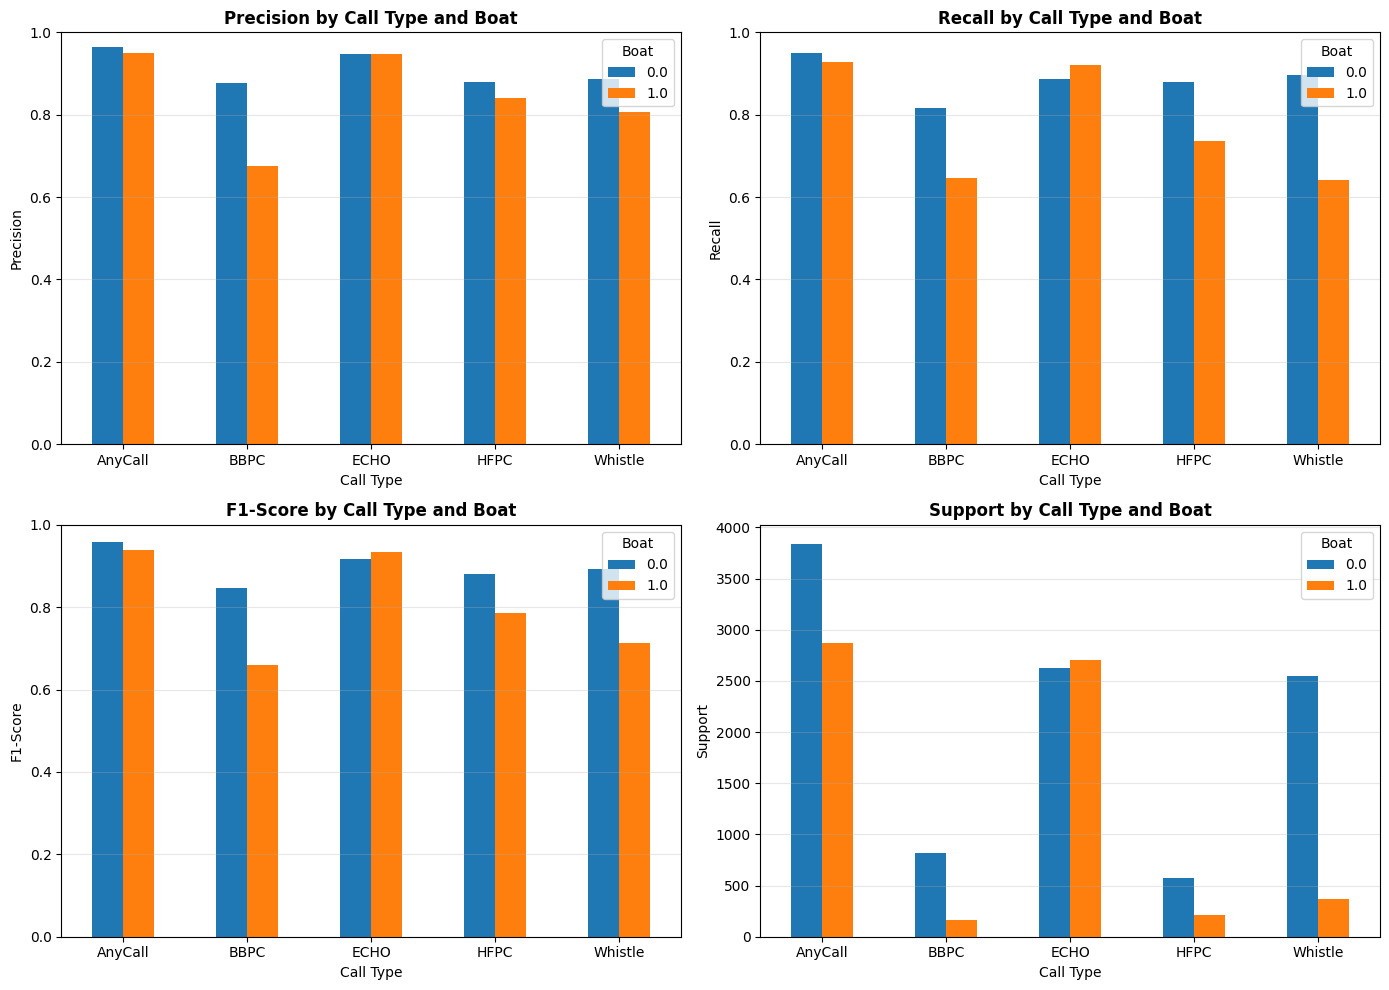

In [54]:




avg_by_context = create_average_metrics_dataframe(
    metrics_overall, metrics_by_context, group_name="Boat"
)
print_average_metrics(avg_by_context, "Boat")


# Create summary dataframes
summary_by_context = create_summary_dataframe(
    metrics_overall, metrics_by_context, call_types, group_name="Boat"
)

# Plot
fig_context = plot_metrics_comparison(
    summary_by_context, group_name="Boat", exclude_overall=True
)
plt.show()

In [55]:
avg_by_context

,Boat,Macro Avg Precision,Macro Avg Recall,Macro Avg F1,Micro Avg F1,False Alarm Rate,Samples Avg F1,n_samples
0,Overall,0.899173,0.867622,0.883041,0.915761,{},0.360274,16835
1,0.0,0.911242,0.886321,0.898344,0.918203,{},0.310928,11163
2,1.0,0.843624,0.774204,0.806195,0.911715,{},0.457392,5672


## False Alarm Rate

## looking at the errors spectrograms

In [56]:
test_predictions_df["ECHO_correct"] = test_predictions_df["ECHO_pred"] == test_predictions_df["ECHO_true"]
test_predictions_df["BBPC_correct"] = test_predictions_df["BBPC_pred"] == test_predictions_df["BBPC_true"]
test_predictions_df["HFPC_correct"] = test_predictions_df["HFPC_pred"] == test_predictions_df["HFPC_true"]
test_predictions_df["Whistle_correct"] = test_predictions_df["Whistle_pred"] == test_predictions_df["Whistle_true"]
test_predictions_df["AnyCall_correct"] = test_predictions_df["AnyCall_pred"] == test_predictions_df["AnyCall_true"]

In [57]:
test_predictions_df

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity,labeling_effort,original_filename,labeled_snippet_filename,Begin Time (s),AnyCall_pred,AnyCall_true,ECHO_correct,BBPC_correct,HFPC_correct,Whistle_correct,AnyCall_correct
0,BSM_20170724_11080300.pt,BSM,0.0,0.0,5.232561e-09,0.0,0.0,3.602791e-09,0.0,0.0,1.564860e-11,0.0,0.0,6.546491e-15,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False,True,True,True,True,True
1,BSM_20170724_11370200.pt,BSM,0.0,0.0,3.873535e-08,0.0,0.0,9.329182e-10,0.0,0.0,1.500955e-10,0.0,0.0,5.086012e-10,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False,True,True,True,True,True
2,BSM_20170724_11370300.pt,BSM,0.0,0.0,3.557386e-11,0.0,0.0,1.807081e-11,0.0,0.0,8.282940e-09,0.0,0.0,1.503849e-06,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False,True,True,True,True,True
3,BSM_20170724_12500300.pt,BSM,0.0,0.0,1.861418e-10,0.0,0.0,1.230424e-09,0.0,0.0,9.414891e-11,0.0,0.0,6.851429e-08,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False,True,True,True,True,True
4,BSM_20170724_13132859.pt,BSM,0.0,0.0,6.516511e-05,0.0,0.0,2.212144e-08,0.0,0.0,3.324768e-04,0.0,1.0,9.999827e-01,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,True,False,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16830,RDL_20200901_19191674.pt,RDL,0.0,0.0,1.202951e-02,0.0,0.0,1.493103e-10,0.0,0.0,2.377552e-08,0.0,0.0,1.776518e-08,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200901190955.wav,NaN,NaN,False,False,True,True,True,True,True
16831,RDL_20200901_19192512.pt,RDL,0.0,0.0,9.348188e-04,0.0,0.0,7.628451e-12,0.0,0.0,2.214313e-09,0.0,0.0,8.463153e-10,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200901190955.wav,NaN,NaN,False,False,True,True,True,True,True
16832,RDL_20200906_14553196.pt,RDL,0.0,0.0,1.637192e-07,0.0,0.0,6.448618e-13,0.0,0.0,3.730531e-09,0.0,0.0,2.633798e-09,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200906144958.wav,NaN,NaN,False,False,True,True,True,True,True
16833,RDL_20200906_14553296.pt,RDL,0.0,0.0,5.529305e-11,0.0,0.0,1.831266e-14,0.0,0.0,4.258700e-10,0.0,0.0,1.828280e-09,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200906144958.wav,NaN,NaN,False,False,True,True,True,True,True


In [58]:
from data_preprocessing.spectrogram.spectrogram_generator import HYDROPHONE_SENSITIVITY, SpectrogramGenerator

spect_generator = SpectrogramGenerator(
        n_fft=2048,
        hop_length=int(2048/2),
        n_mels=64,
        fmin=200,
        sample_rate=192000, 
    )

In [59]:
test_predictions_df["Boat"].value_counts()

Boat
0.0    11163
1.0     5672
Name: count, dtype: int64

In [60]:
labels_df.columns

Index(['clip_filename', 'ECHO', 'BBPC', 'HFPC', 'Whistle', 'Call', 'Boat',
       'labeling_effort', 'DETAIL', 'Begin Time (s)', 'End Time (s)',
       'GROUNDTRUTH', 'Notes', 'original_filename', 'labeled_snippet_filename',
       'snippet_start_time', 'snippet_start_s', 'snippet_end_s', 'Site',
       'labeled_snippet_dir', 'HydrophoneModel', 'HydrophoneSensitivity',
       'clip_start_time', 'clip_end_time', 'DETAILS', 'boat_labeling_file',
       'boat_labeling_file_id', 'annotator', 'SnippetFilename', 'start_s',
       'end_s', 'FIXED_GROUNDTRUTH', 'ClipFilenamePt'],
      dtype='str')

In [61]:
test_predictions_df

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity,labeling_effort,original_filename,labeled_snippet_filename,Begin Time (s),AnyCall_pred,AnyCall_true,ECHO_correct,BBPC_correct,HFPC_correct,Whistle_correct,AnyCall_correct
0,BSM_20170724_11080300.pt,BSM,0.0,0.0,5.232561e-09,0.0,0.0,3.602791e-09,0.0,0.0,1.564860e-11,0.0,0.0,6.546491e-15,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False,True,True,True,True,True
1,BSM_20170724_11370200.pt,BSM,0.0,0.0,3.873535e-08,0.0,0.0,9.329182e-10,0.0,0.0,1.500955e-10,0.0,0.0,5.086012e-10,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False,True,True,True,True,True
2,BSM_20170724_11370300.pt,BSM,0.0,0.0,3.557386e-11,0.0,0.0,1.807081e-11,0.0,0.0,8.282940e-09,0.0,0.0,1.503849e-06,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False,True,True,True,True,True
3,BSM_20170724_12500300.pt,BSM,0.0,0.0,1.861418e-10,0.0,0.0,1.230424e-09,0.0,0.0,9.414891e-11,0.0,0.0,6.851429e-08,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False,True,True,True,True,True
4,BSM_20170724_13132859.pt,BSM,0.0,0.0,6.516511e-05,0.0,0.0,2.212144e-08,0.0,0.0,3.324768e-04,0.0,1.0,9.999827e-01,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,True,False,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16830,RDL_20200901_19191674.pt,RDL,0.0,0.0,1.202951e-02,0.0,0.0,1.493103e-10,0.0,0.0,2.377552e-08,0.0,0.0,1.776518e-08,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200901190955.wav,NaN,NaN,False,False,True,True,True,True,True
16831,RDL_20200901_19192512.pt,RDL,0.0,0.0,9.348188e-04,0.0,0.0,7.628451e-12,0.0,0.0,2.214313e-09,0.0,0.0,8.463153e-10,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200901190955.wav,NaN,NaN,False,False,True,True,True,True,True
16832,RDL_20200906_14553196.pt,RDL,0.0,0.0,1.637192e-07,0.0,0.0,6.448618e-13,0.0,0.0,3.730531e-09,0.0,0.0,2.633798e-09,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200906144958.wav,NaN,NaN,False,False,True,True,True,True,True
16833,RDL_20200906_14553296.pt,RDL,0.0,0.0,5.529305e-11,0.0,0.0,1.831266e-14,0.0,0.0,4.258700e-10,0.0,0.0,1.828280e-09,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200906144958.wav,NaN,NaN,False,False,True,True,True,True,True


In [62]:
sample = test_predictions_df[(test_predictions_df["Boat"] == 1)& (test_predictions_df["AnyCall_correct"] == False) & (test_predictions_df["AnyCall_true"] == 0)]
sample


,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity,labeling_effort,original_filename,labeled_snippet_filename,Begin Time (s),AnyCall_pred,AnyCall_true,ECHO_correct,BBPC_correct,HFPC_correct,Whistle_correct,AnyCall_correct
63,BSM_20170725_06092700.pt,BSM,0.0,0.0,6.995274e-06,0.0,0.0,1.248516e-05,0.0,1.0,5.243004e-01,0.0,0.0,6.637732e-08,0,1.0,-172.7,evaluation_v2,201359382.170725053002.wav,201359382.170725060901.snippet.wav,26.0,True,False,True,False,True,True,False
80,BSM_20170725_06094400.pt,BSM,0.0,1.0,9.677105e-01,0.0,0.0,1.320746e-03,0.0,0.0,3.470315e-04,0.0,0.0,5.555002e-06,0,1.0,-172.7,evaluation_v2,201359382.170725053002.wav,201359382.170725060901.snippet.wav,43.0,True,False,False,True,True,True,False
2435,CAC_20210718_08551200.pt,CAC,0.0,0.0,2.999938e-07,0.0,0.0,1.300739e-06,0.0,0.0,3.413687e-06,0.0,1.0,7.858604e-01,0,1.0,-172.7,evaluation_v2,201359382.210718075958.wav,201359382.210718085424.snippet.wav,48.0,True,False,True,True,True,False,False
2593,CAC_20210718_19290600.pt,CAC,0.0,0.0,6.920700e-02,0.0,0.0,3.156148e-05,0.0,1.0,8.022002e-01,0.0,0.0,1.882309e-04,0,1.0,-172.7,evaluation_v2,201359382.210718182950.wav,201359382.210718192740.snippet.wav,86.0,True,False,True,False,True,True,False
3051,KAM_20200729_10220000.pt,KAM,0.0,1.0,5.861062e-01,0.0,0.0,1.250551e-07,0.0,0.0,3.237652e-07,0.0,0.0,9.557678e-08,0,1.0,-175.7,evaluation_v2,5725.200729095958.wav,5725.200729102125.snippet.wav,35.0,True,False,False,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16278,KAM_20200731_14040400.pt,KAM,0.0,1.0,9.999297e-01,0.0,0.0,8.979464e-08,0.0,0.0,3.700449e-08,0.0,0.0,3.611859e-09,4,1.0,-175.7,evaluation_v2,5725.200731135954.wav,5725.200731140339.snippet.wav,25.0,True,False,False,True,True,True,False
16283,KAM_20200731_14040900.pt,KAM,0.0,1.0,9.982768e-01,0.0,0.0,1.257853e-07,0.0,0.0,5.860248e-07,0.0,0.0,7.777841e-08,4,1.0,-175.7,evaluation_v2,5725.200731135954.wav,5725.200731140339.snippet.wav,30.0,True,False,False,True,True,True,False
16300,KAM_20200731_14042600.pt,KAM,0.0,1.0,9.999208e-01,0.0,0.0,1.994941e-08,0.0,0.0,1.169811e-01,0.0,0.0,8.163737e-06,4,1.0,-175.7,evaluation_v2,5725.200731135954.wav,5725.200731140339.snippet.wav,47.0,True,False,False,True,True,True,False
16464,KAM_20200801_15212900.pt,KAM,0.0,1.0,8.921298e-01,0.0,0.0,7.652817e-08,0.0,0.0,6.118557e-09,0.0,0.0,1.750243e-09,4,1.0,-175.7,evaluation_v2,5725.200801145954.wav,5725.200801152155.snippet.wav,24.0,True,False,False,True,True,True,False


0/133
15.0
evaluation_v1
12877    5725.200726191905.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19192000.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


c:\Users\Admin\Desktop\Emmanuel\beluga-call-pipeline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


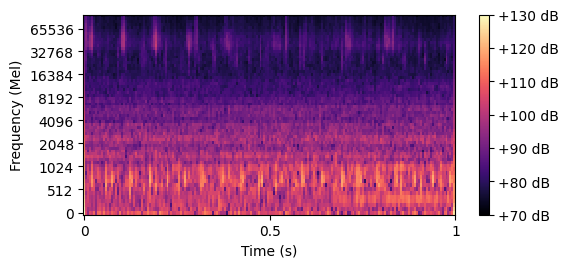

1/133
33.0
evaluation_v1
12895    5725.200726191905.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19193800.wav
ECHO: true 1 vs pred 1   HFPC: true 1 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


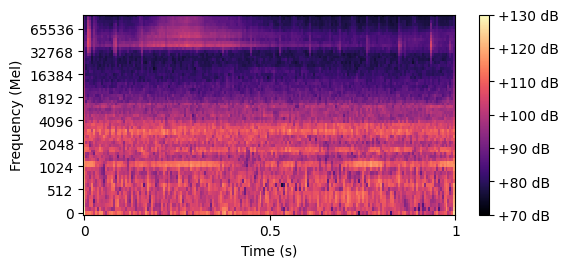

2/133
34.0
evaluation_v1
12896    5725.200726191905.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19193900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 0   Whistle: true 1 vs pred 0


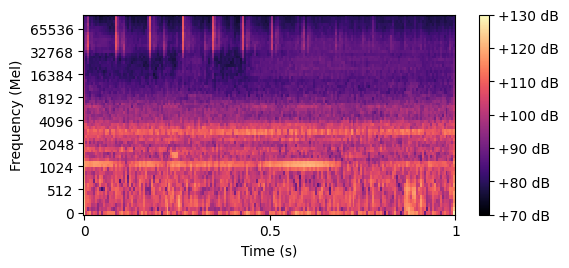

3/133
36.0
evaluation_v1
12898    5725.200726191905.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19194100.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


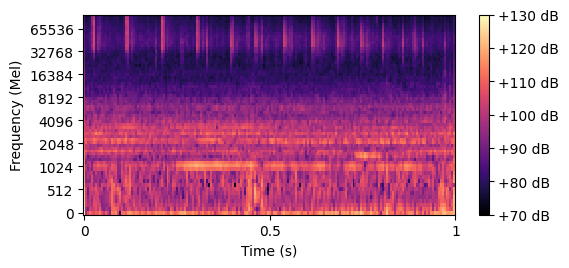

4/133
112.0
evaluation_v1
12974    5725.200726191905.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19205700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


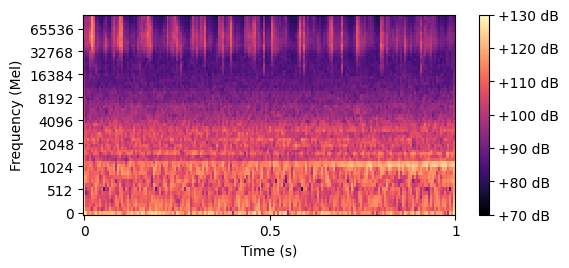

5/133
142.0
evaluation_v1
13004    5725.200726191905.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19212700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


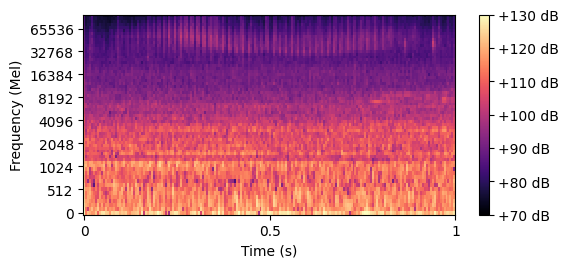

6/133
341.0
evaluation_v1
13203    5725.200726191905.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19244600.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


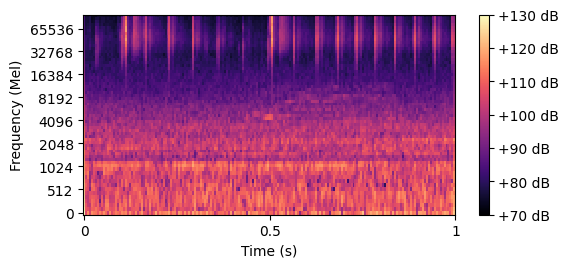

7/133
345.0
evaluation_v1
13207    5725.200726191905.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19245000.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


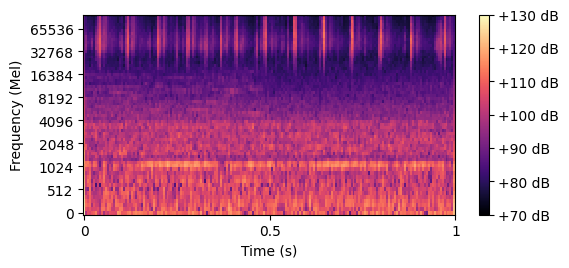

8/133
nan
irene_20min
3915    NaN
Name: labeled_snippet_filename, dtype: str
BSM_20170812_16291650.wav
ECHO: true 1 vs pred 1   HFPC: true 1 vs pred 1   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


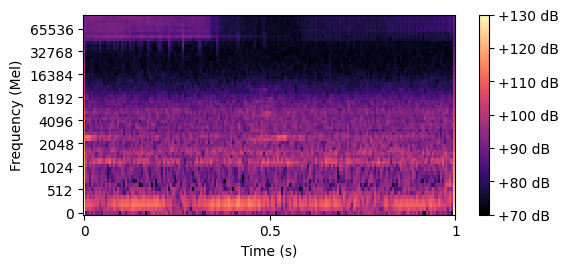

9/133
1.0
evaluation_v2
11991    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13290600.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


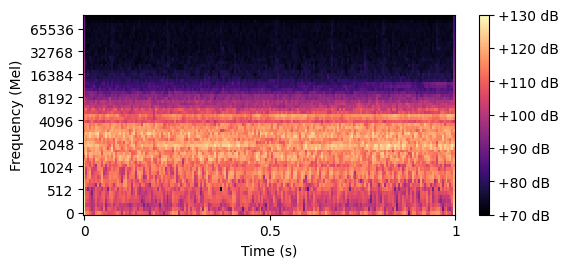

10/133
2.0
evaluation_v2
11992    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13290700.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


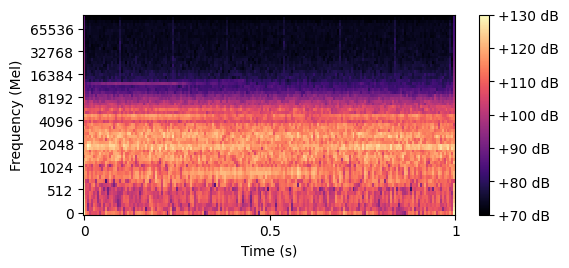

11/133
6.0
evaluation_v2
11996    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13291100.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


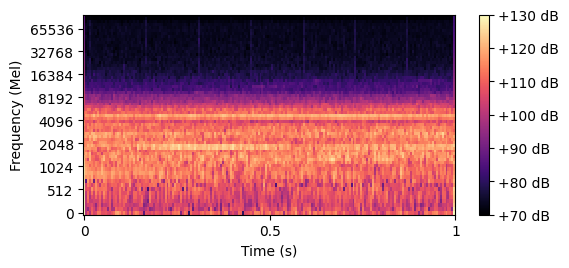

12/133
8.0
evaluation_v2
11998    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13291300.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


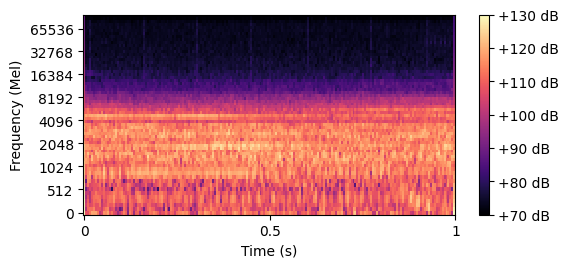

13/133
26.0
evaluation_v2
12016    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13293100.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


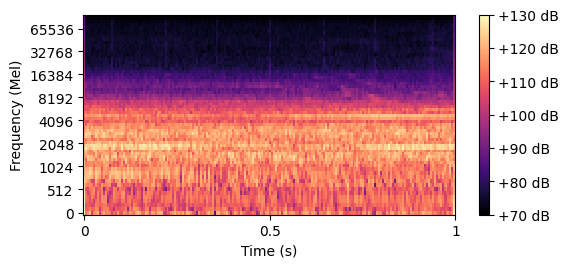

14/133
27.0
evaluation_v2
12017    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13293200.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


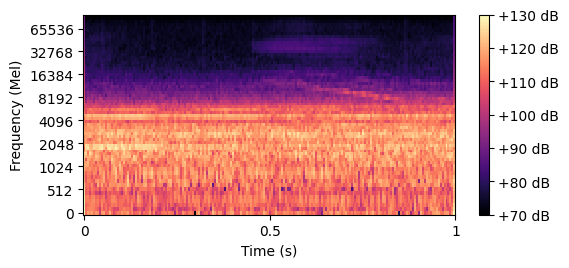

15/133
28.0
evaluation_v2
12018    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13293300.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


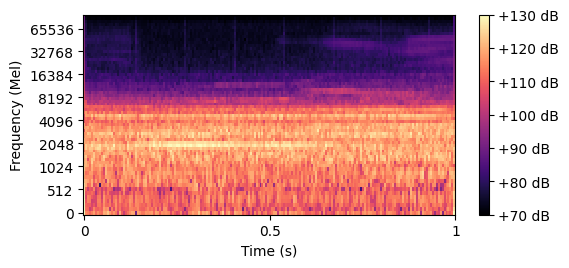

16/133
29.0
evaluation_v2
12019    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13293400.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 0   Whistle: true 1 vs pred 0


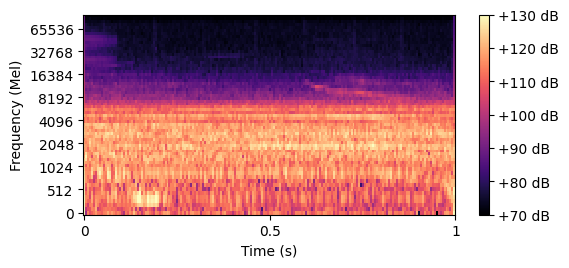

17/133
36.0
evaluation_v2
12026    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13294100.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


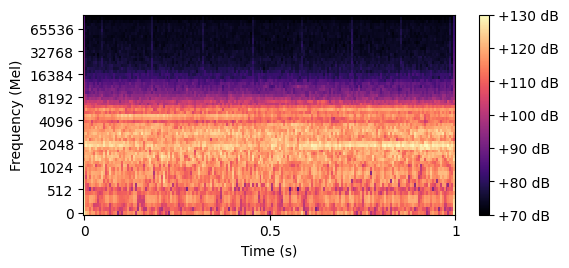

18/133
38.0
evaluation_v2
12028    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13294300.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


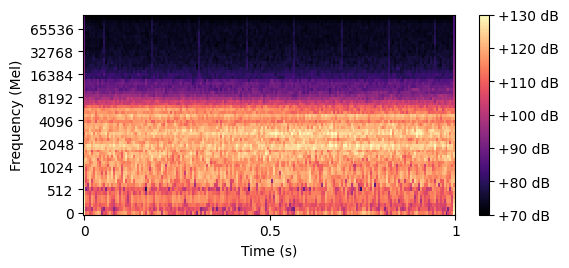

19/133
39.0
evaluation_v2
12029    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13294400.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


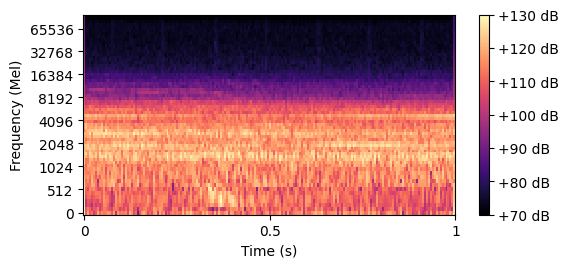

20/133
79.0
evaluation_v2
12069    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13302400.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


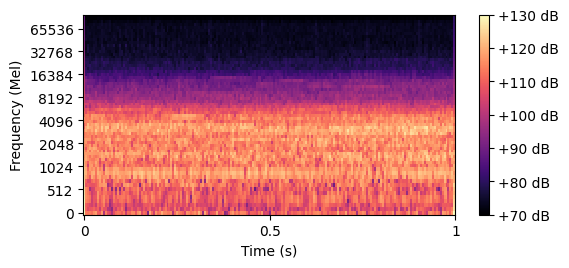

21/133
80.0
evaluation_v2
12070    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13302500.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


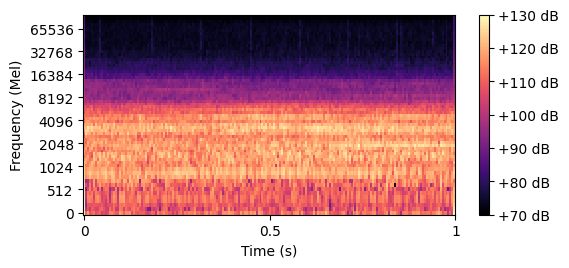

22/133
205.0
evaluation_v1
13421    5725.200726195504.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19582900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 1   Whistle: true 1 vs pred 0


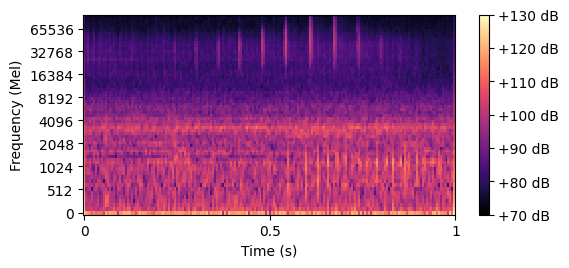

23/133
206.0
evaluation_v1
13422    5725.200726195504.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19583000.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


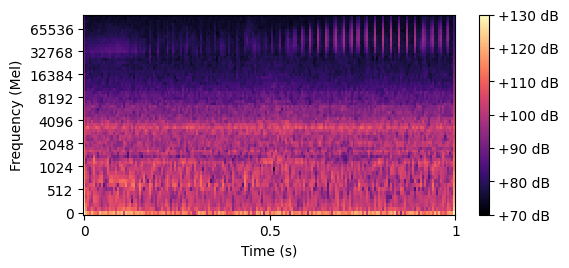

24/133
215.0
evaluation_v1
13431    5725.200726195504.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19583900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


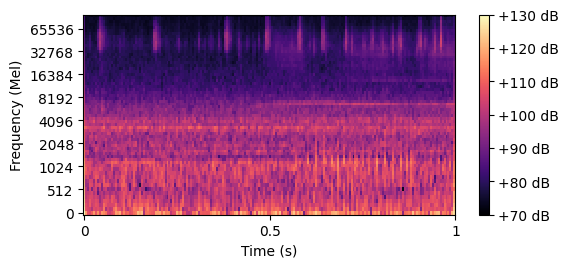

25/133
238.0
evaluation_v1
13454    5725.200726195504.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19590200.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


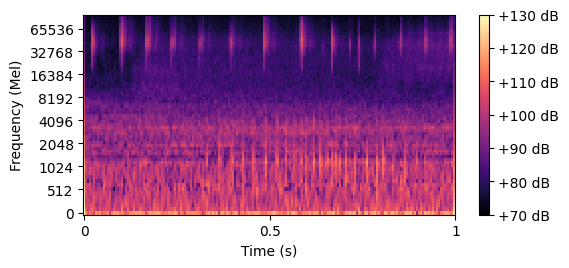

26/133
nan
irene_5min
16163    NaN
Name: labeled_snippet_filename, dtype: str
KAM_20210805_15244500.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


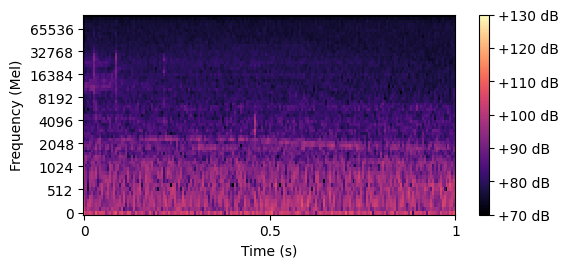

27/133
nan
irene_5min
3627    NaN
Name: labeled_snippet_filename, dtype: str
BSM_20170808_14123250.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


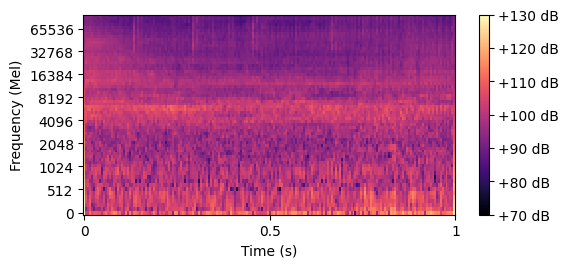

28/133
2.0
evaluation_v1
8993    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08305500.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


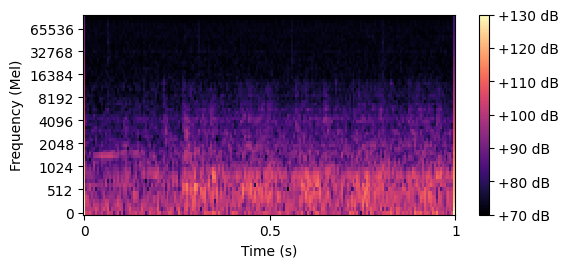

29/133
94.0
evaluation_v1
9088    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08322700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


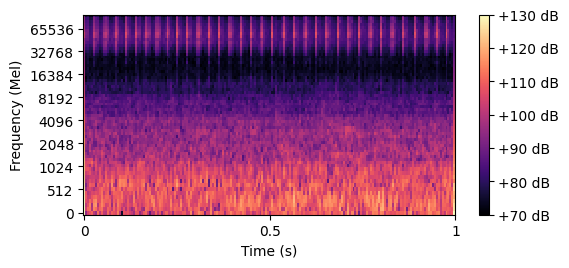

30/133
97.0
evaluation_v1
9091    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08323000.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


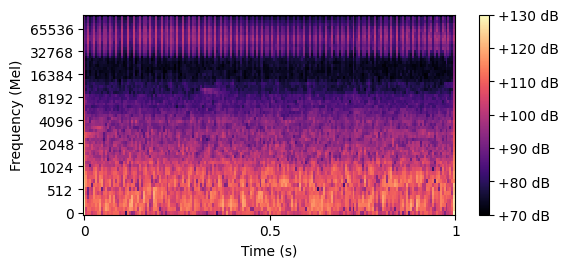

31/133
102.0
evaluation_v1
9096    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08323500.wav
ECHO: true 1 vs pred 0   HFPC: true 1 vs pred 1   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


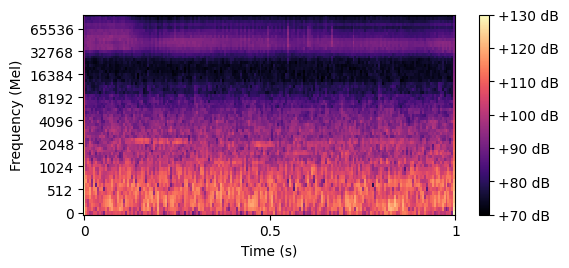

32/133
110.0
evaluation_v1
9104    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08324300.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


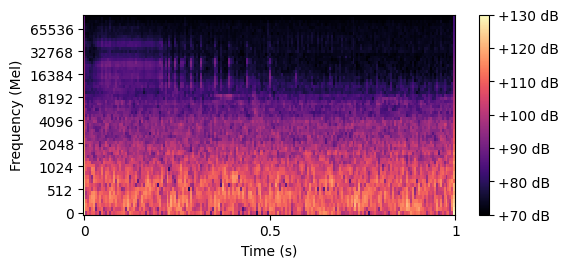

33/133
120.0
evaluation_v1
9114    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08325300.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


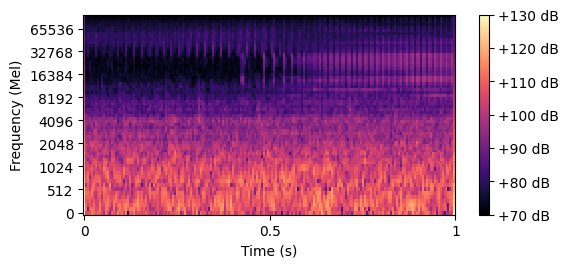

34/133
125.0
evaluation_v1
9119    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08325800.wav
ECHO: true 0 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


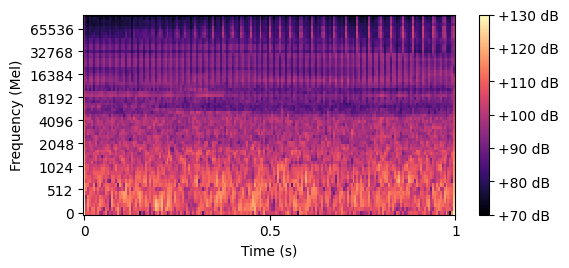

35/133
126.0
evaluation_v1
9120    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08325900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


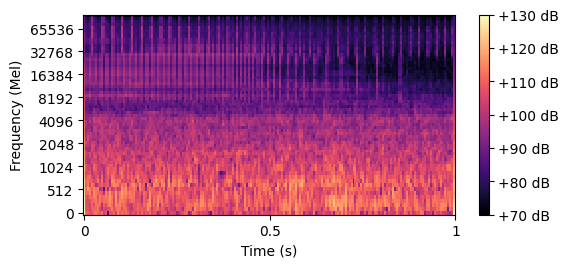

36/133
129.0
evaluation_v1
9123    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08330200.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


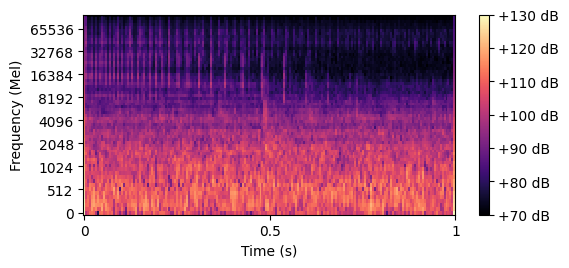

37/133
133.0
evaluation_v1
9127    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08330600.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 0   Whistle: true 1 vs pred 0


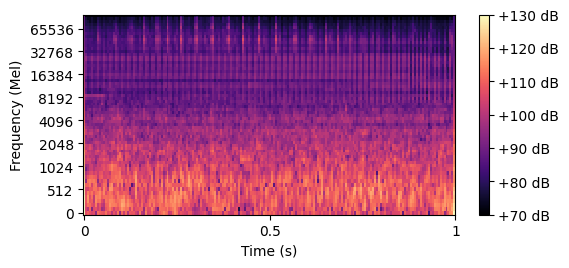

38/133
139.0
evaluation_v1
9133    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08331200.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


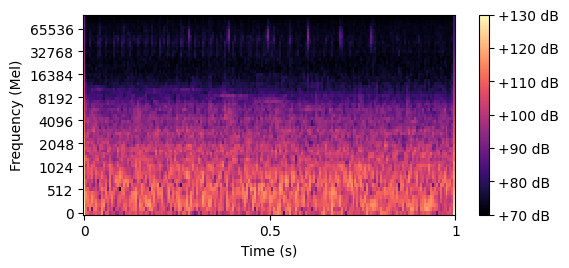

39/133
143.0
evaluation_v1
9137    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08331600.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


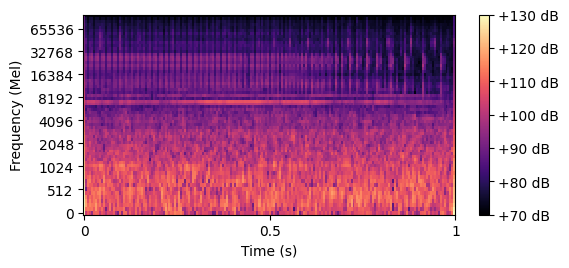

40/133
166.0
evaluation_v1
9163    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08333900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


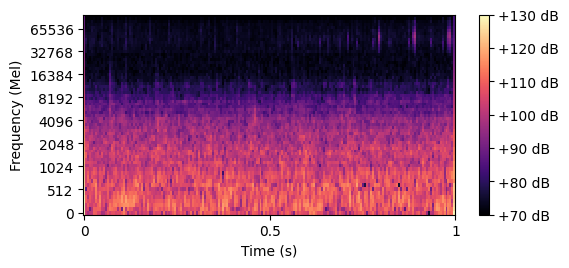

41/133
167.0
evaluation_v1
9164    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08334000.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


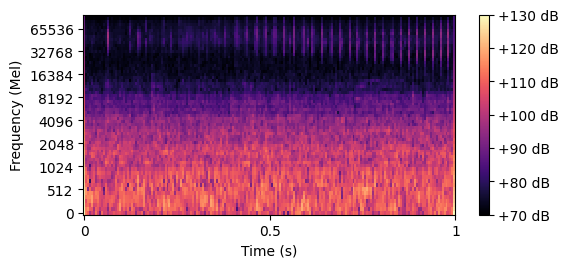

42/133
172.0
evaluation_v1
9169    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08334500.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


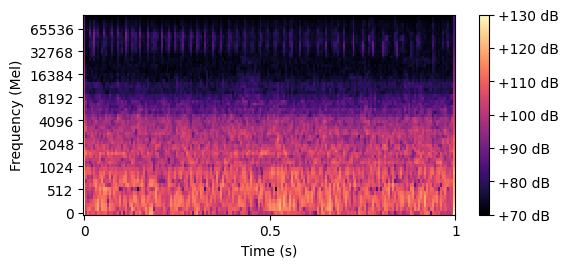

43/133
174.0
evaluation_v1
9171    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08334700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


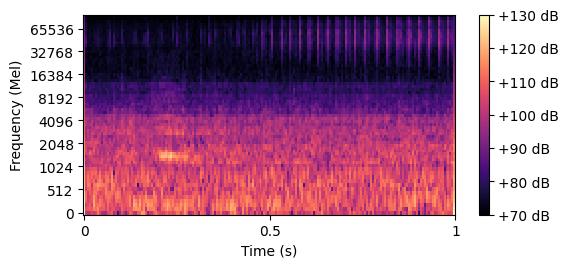

44/133
175.0
evaluation_v1
9172    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08334800.wav
ECHO: true 1 vs pred 1   HFPC: true 1 vs pred 1   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


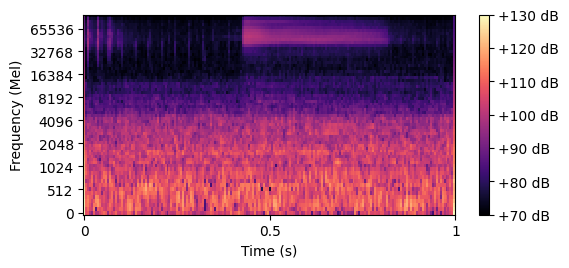

45/133
195.0
evaluation_v1
9192    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08340800.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


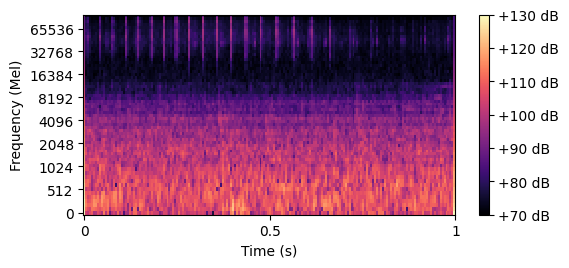

46/133
196.0
evaluation_v1
9193    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08340900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


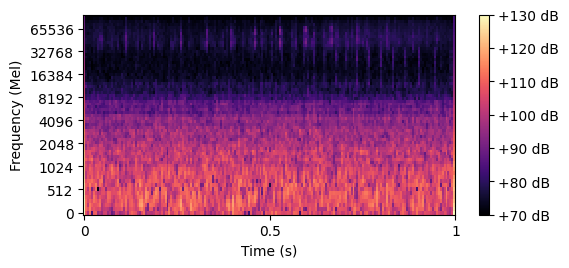

47/133
214.0
evaluation_v1
9211    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08342700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


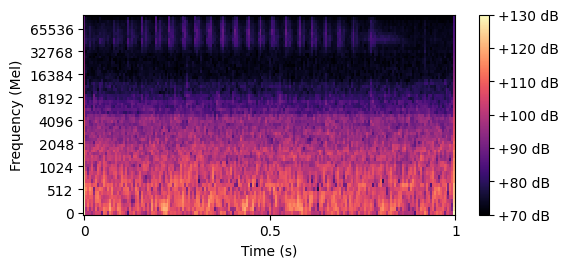

48/133
215.0
evaluation_v1
9212    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08342800.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


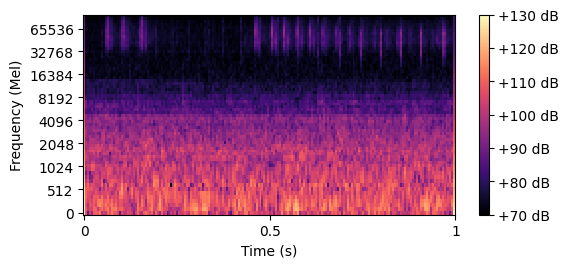

49/133
258.0
evaluation_v1
9255    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08351100.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


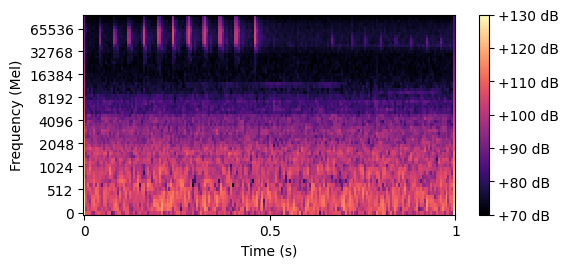

50/133
259.0
evaluation_v1
9256    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08351200.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


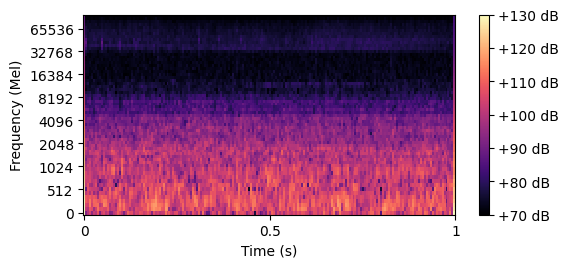

51/133
260.0
evaluation_v1
9257    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08351300.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


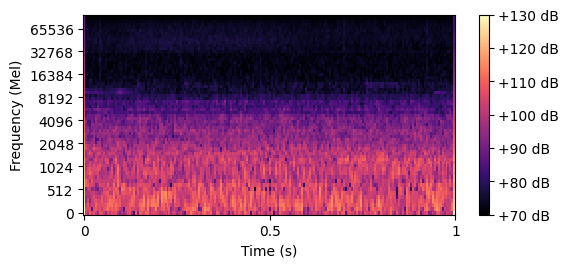

52/133
261.0
evaluation_v1
9258    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08351400.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


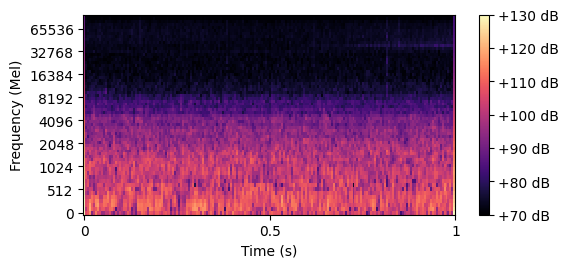

53/133
262.0
evaluation_v1
9259    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08351500.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


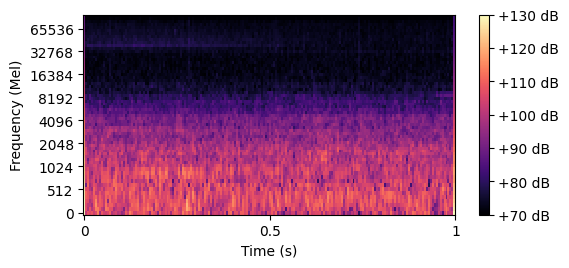

54/133
263.0
evaluation_v1
9260    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08351600.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


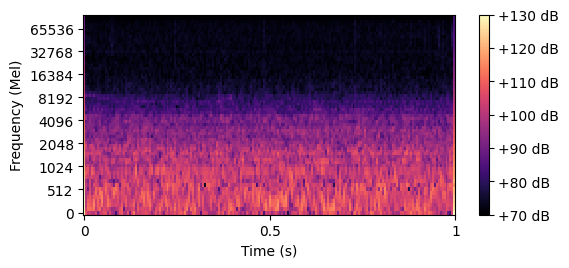

55/133
268.0
evaluation_v1
9265    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08352100.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


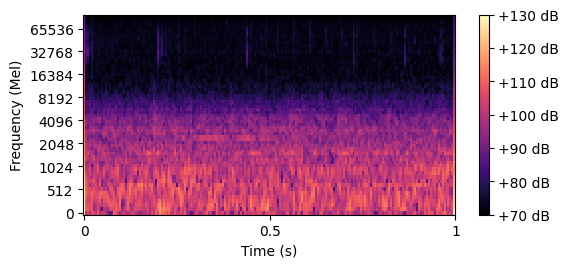

56/133
294.0
evaluation_v1
9291    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08354700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


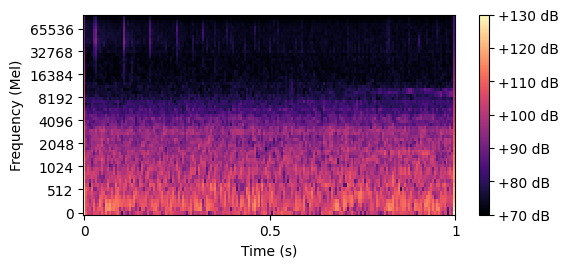

57/133
295.0
evaluation_v1
9292    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08354800.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


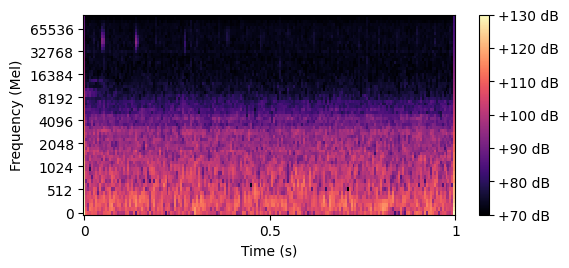

58/133
306.0
evaluation_v1
9303    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08355900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


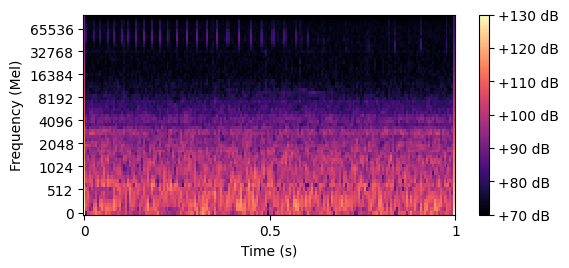

59/133
307.0
evaluation_v1
9304    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08360000.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


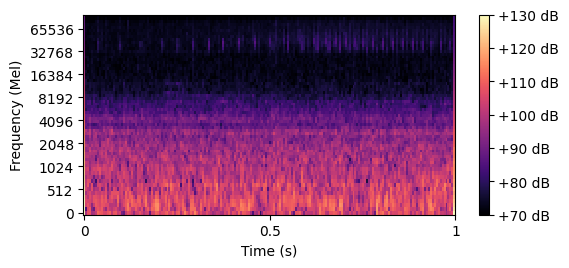

60/133
310.0
evaluation_v1
9307    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08360300.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


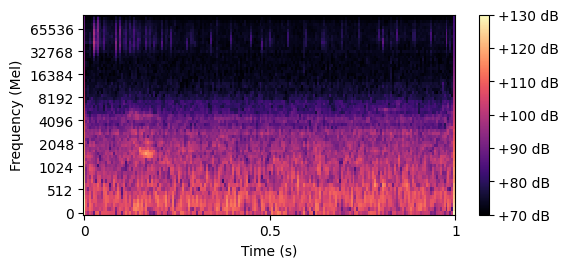

61/133
311.0
evaluation_v1
9308    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08360400.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


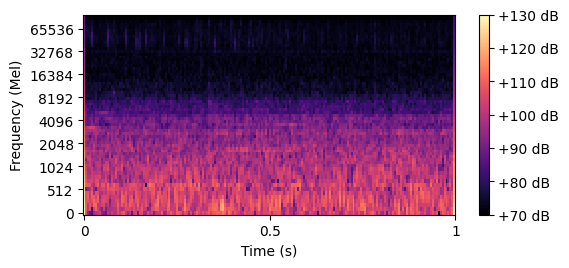

62/133
312.0
evaluation_v1
9309    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08360500.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


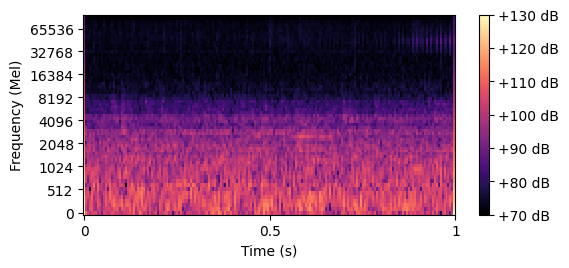

63/133
319.0
evaluation_v1
9316    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08361200.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


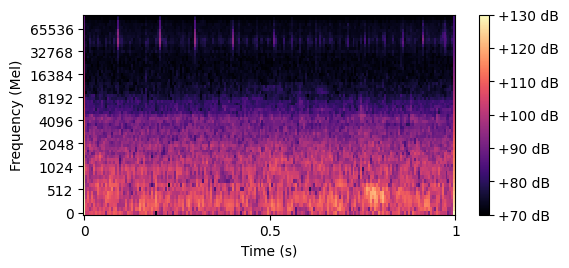

64/133
320.0
evaluation_v1
9317    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08361300.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


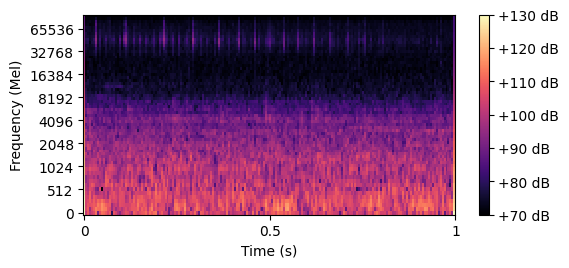

65/133
321.0
evaluation_v1
9318    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08361400.wav
ECHO: true 1 vs pred 0   HFPC: true 1 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


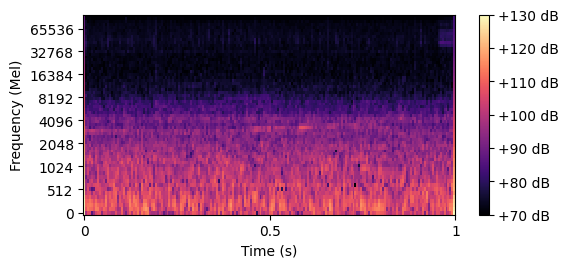

66/133
328.0
evaluation_v1
9330    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08362100.wav
ECHO: true 0 vs pred 0   HFPC: true 1 vs pred 1   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


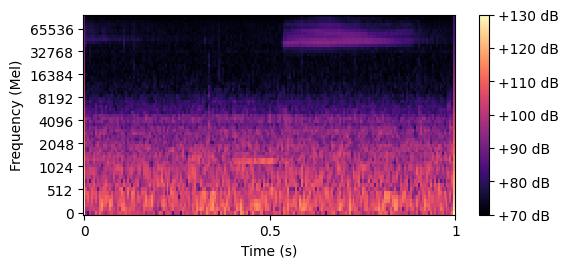

67/133
330.0
evaluation_v1
9334    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08362300.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


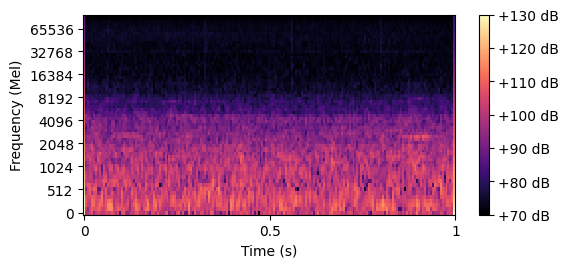

68/133
331.0
evaluation_v1
9336    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08362400.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


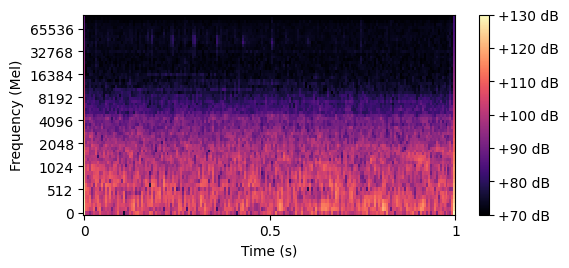

69/133
339.0
evaluation_v1
9344    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08363200.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


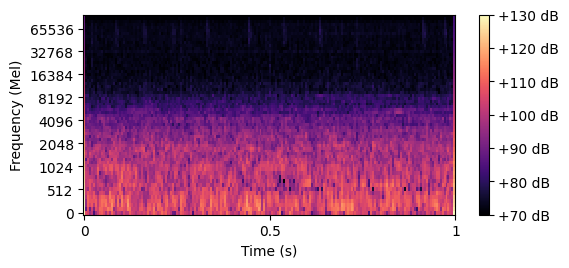

70/133
343.0
evaluation_v1
9350    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08363600.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


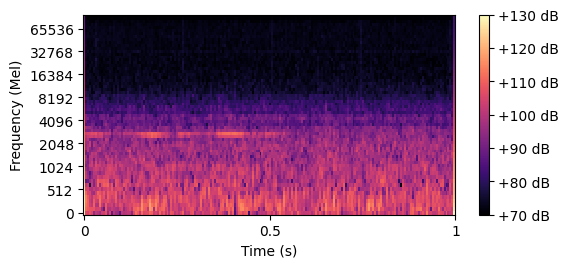

71/133
349.0
evaluation_v1
9360    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08364200.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


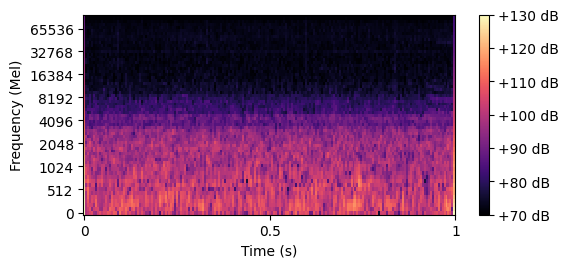

72/133
350.0
evaluation_v1
9362    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08364300.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


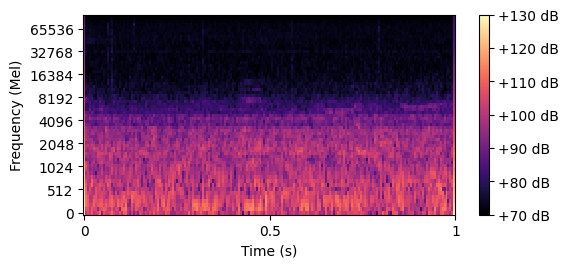

73/133
352.0
evaluation_v1
9364    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08364500.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


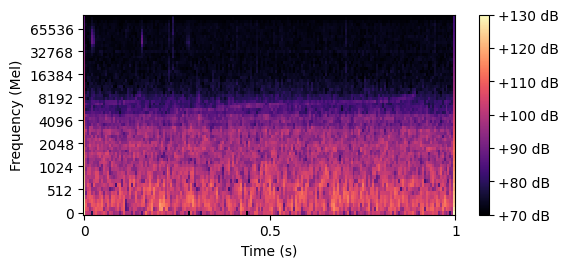

74/133
354.0
evaluation_v1
9366    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08364700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


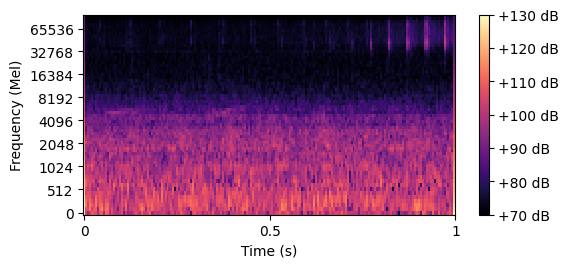

75/133
361.0
evaluation_v1
9373    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08365400.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


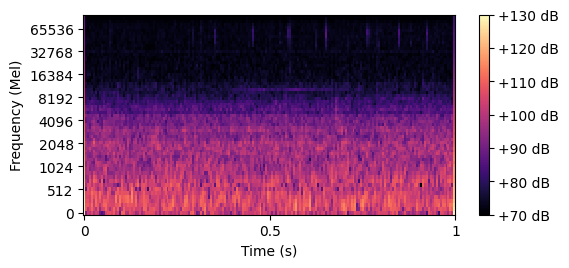

76/133
362.0
evaluation_v1
9374    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08365500.wav
ECHO: true 1 vs pred 1   HFPC: true 1 vs pred 1   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


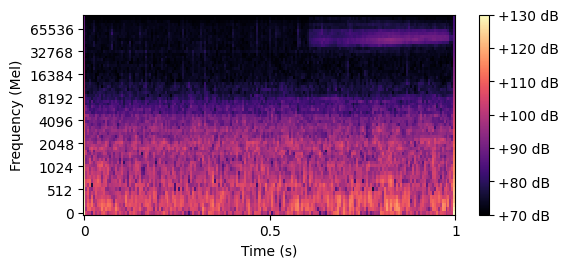

77/133
363.0
evaluation_v1
9375    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08365600.wav
ECHO: true 0 vs pred 0   HFPC: true 1 vs pred 0   BBPC: true 0 vs pred 1   Whistle: true 1 vs pred 0


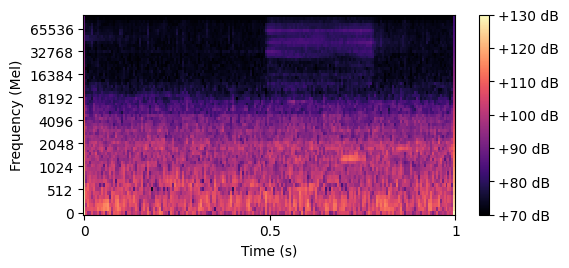

78/133
369.0
evaluation_v1
9381    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08370200.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


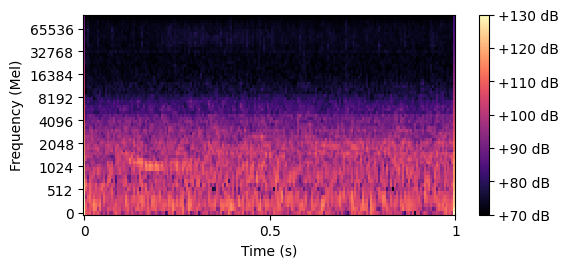

79/133
370.0
evaluation_v1
9382    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08370300.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


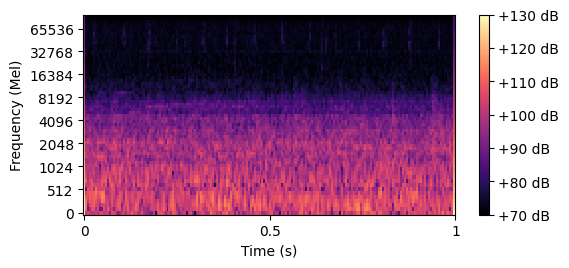

80/133
371.0
evaluation_v1
9383    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08370400.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


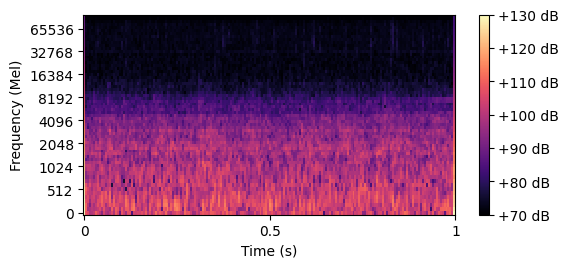

81/133
372.0
evaluation_v1
9384    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08370500.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


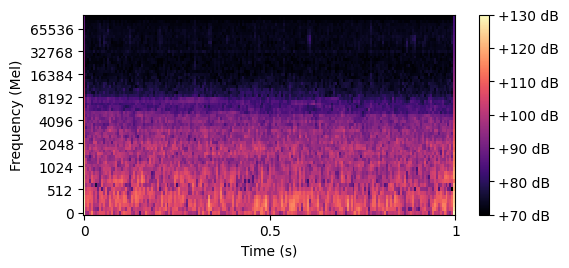

82/133
378.0
evaluation_v1
9390    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08371100.wav
ECHO: true 0 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


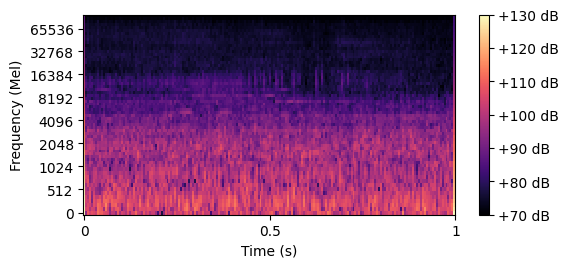

83/133
387.0
evaluation_v1
9399    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08372000.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


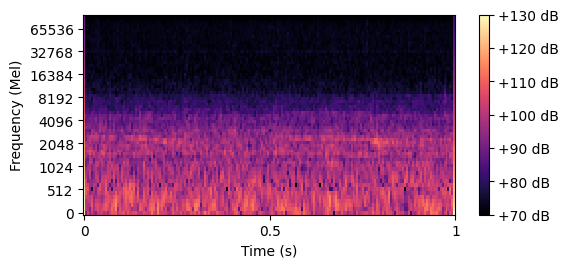

84/133
388.0
evaluation_v1
9400    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08372100.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


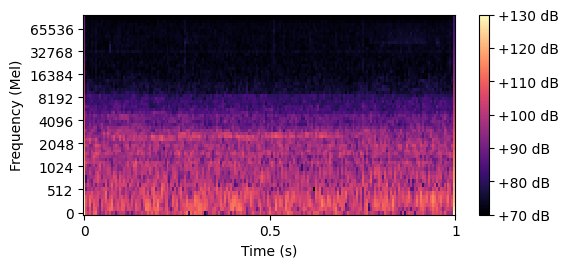

85/133
392.0
evaluation_v1
9404    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08372500.wav
ECHO: true 0 vs pred 1   HFPC: true 1 vs pred 1   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


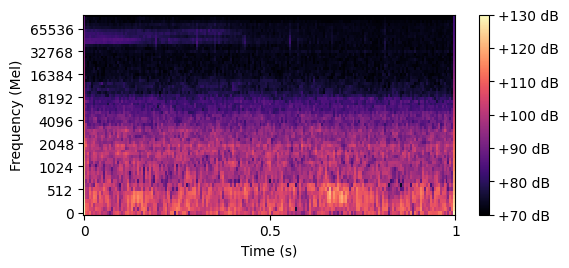

86/133
404.0
evaluation_v1
9422    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08373700.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


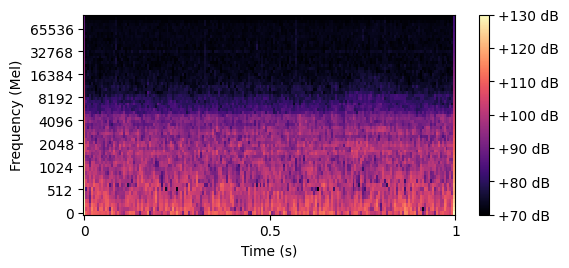

87/133
424.0
evaluation_v1
9442    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08375700.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


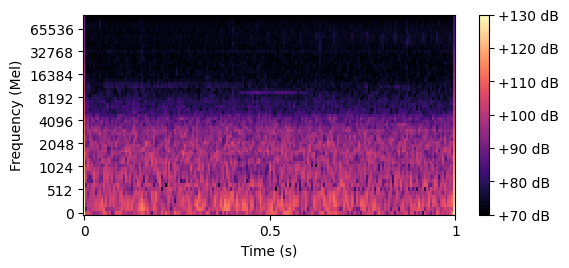

88/133
428.0
evaluation_v1
9446    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08380100.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


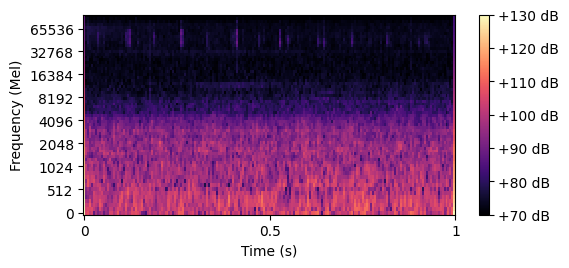

89/133
429.0
evaluation_v1
9447    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08380200.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


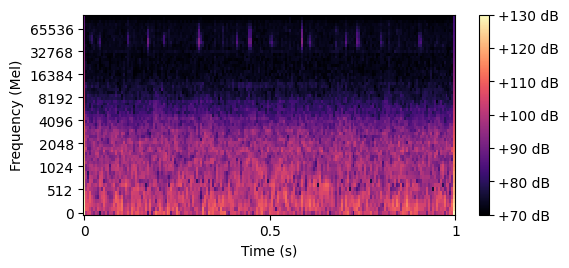

90/133
430.0
evaluation_v1
9448    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08380300.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


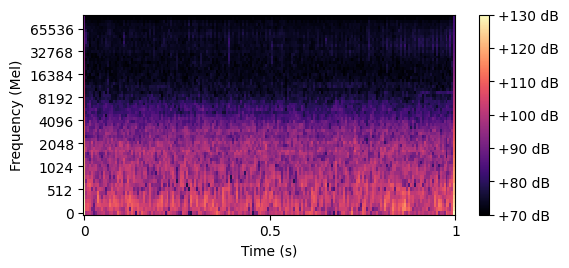

91/133
431.0
evaluation_v1
9449    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08380400.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


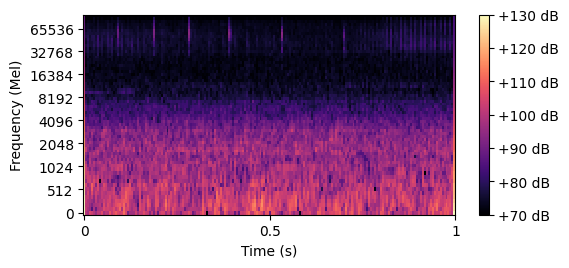

92/133
435.0
evaluation_v1
9453    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08380800.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


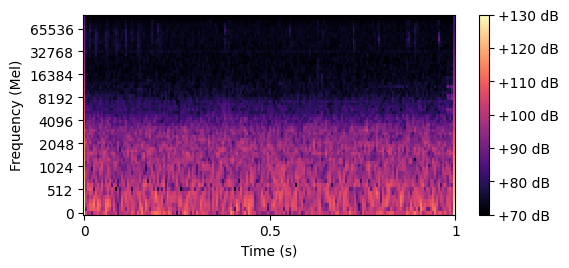

93/133
437.0
evaluation_v1
9455    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08381000.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


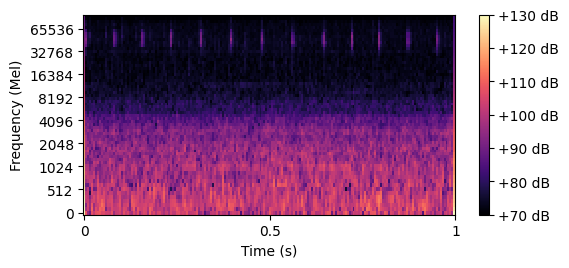

94/133
444.0
evaluation_v1
9462    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08381700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


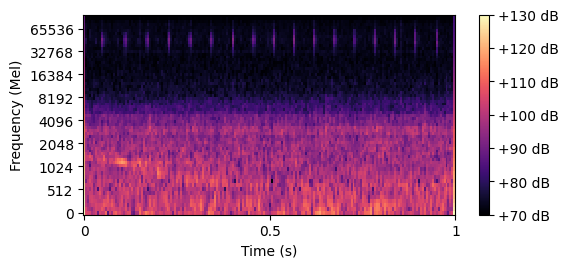

95/133
445.0
evaluation_v1
9463    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08381800.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


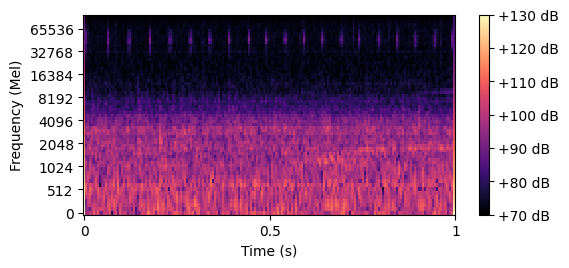

96/133
446.0
evaluation_v1
9464    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08381900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


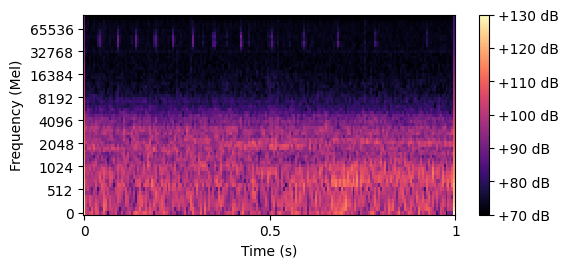

97/133
451.0
evaluation_v1
9469    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08382400.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


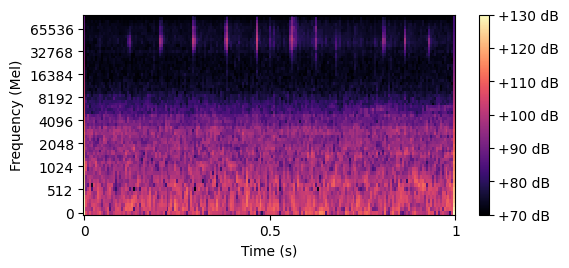

98/133
452.0
evaluation_v1
9470    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08382500.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


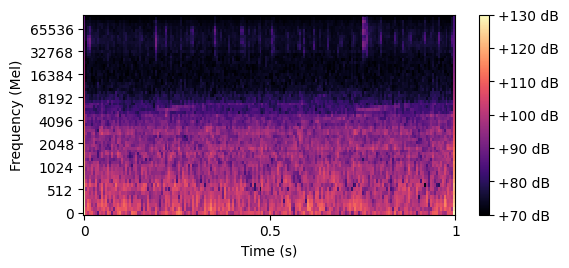

99/133
453.0
evaluation_v1
9471    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08382600.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


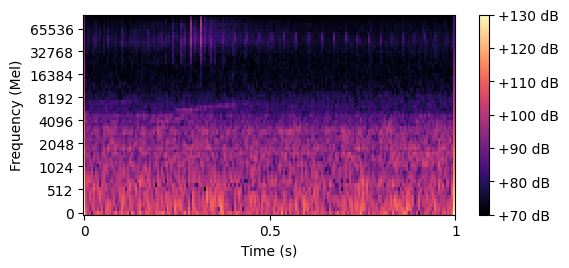

100/133
460.0
evaluation_v1
9478    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08383300.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


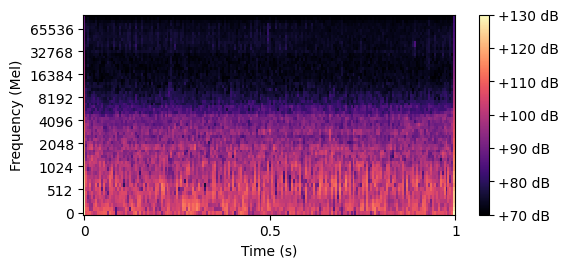

101/133
461.0
evaluation_v1
9479    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08383400.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 1   Whistle: true 1 vs pred 0


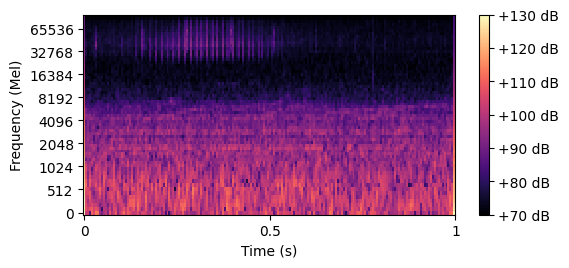

102/133
464.0
evaluation_v1
9482    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08383700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


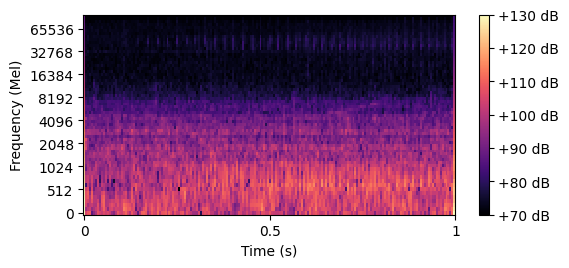

103/133
479.0
evaluation_v1
9503    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08385200.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


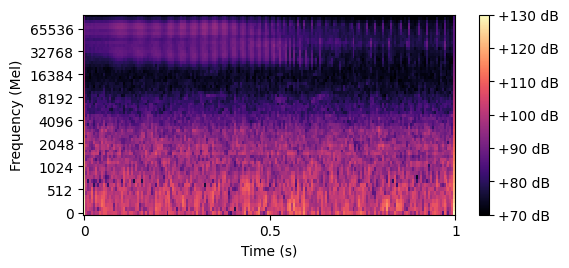

104/133
485.0
evaluation_v1
9509    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08385800.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


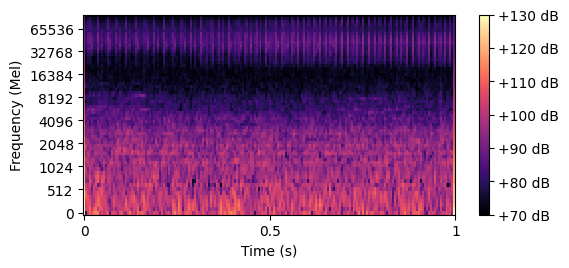

105/133
488.0
evaluation_v1
9512    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08390100.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


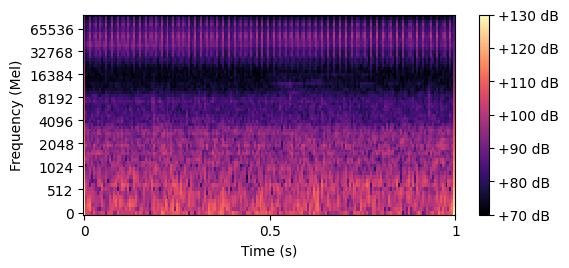

106/133
489.0
evaluation_v1
9513    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08390200.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


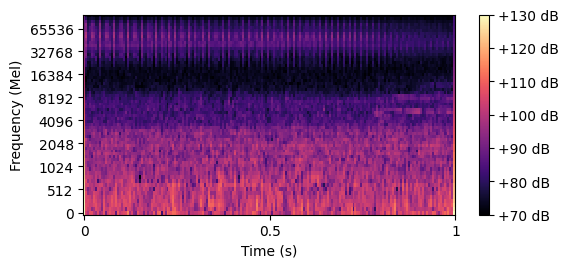

107/133
490.0
evaluation_v1
9514    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08390300.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


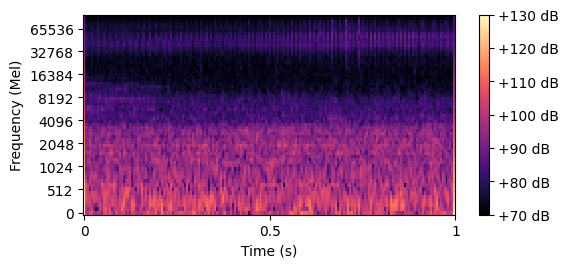

108/133
493.0
evaluation_v1
9517    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08390600.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


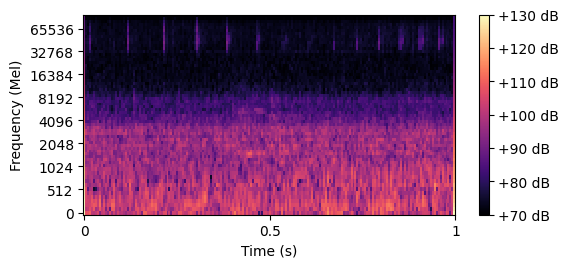

109/133
502.0
evaluation_v1
9526    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08391500.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 1   BBPC: true 0 vs pred 1   Whistle: true 1 vs pred 0


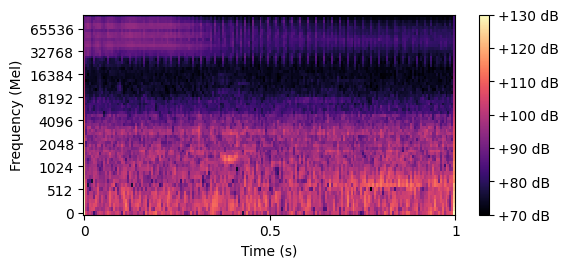

110/133
509.0
evaluation_v1
9533    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08392200.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


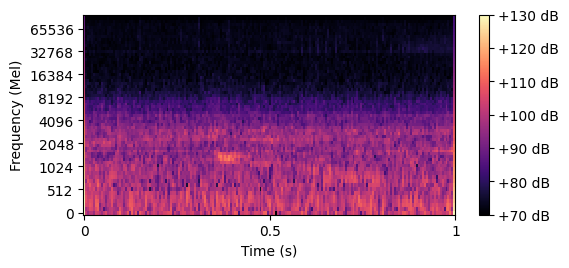

111/133
532.0
evaluation_v1
9557    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08394500.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


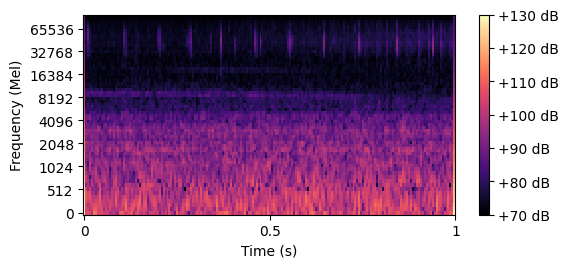

112/133
549.0
evaluation_v1
9577    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08400200.wav
ECHO: true 1 vs pred 1   HFPC: true 1 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


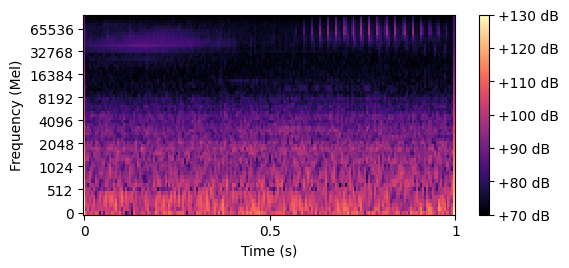

113/133
567.0
evaluation_v1
9595    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08402000.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


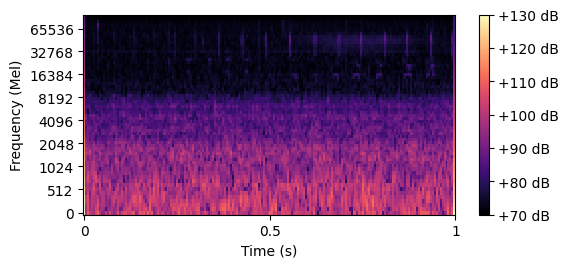

114/133
575.0
evaluation_v1
9603    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08402800.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


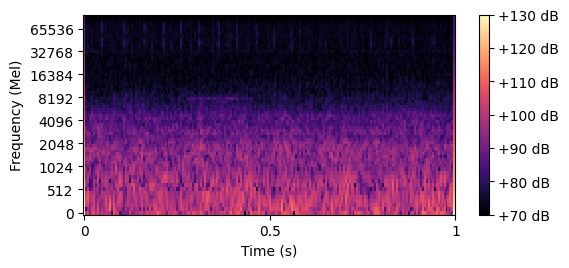

115/133
87.0
evaluation_v2
13680    5725.200729113050.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200729_11321700.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


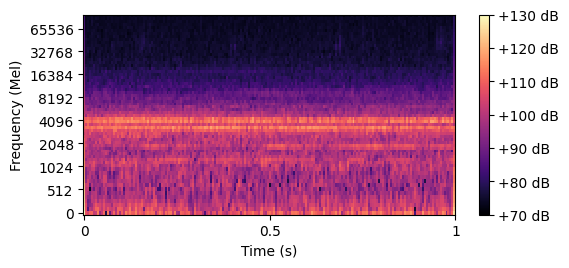

116/133
nan
irene_20min
9410    NaN
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08372848.wav
ECHO: true 0 vs pred 0   HFPC: true 1 vs pred 1   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


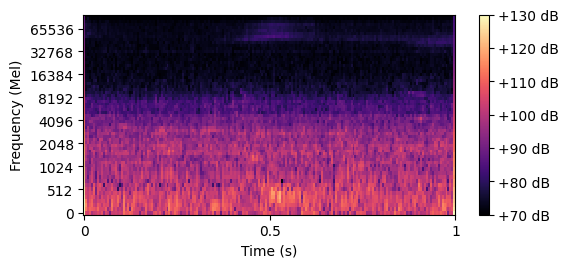

117/133
195.0
evaluation_v2
15171    5725.200801150830.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200801_15114500.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


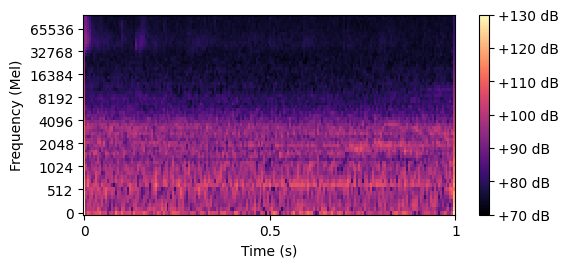

118/133
196.0
evaluation_v2
15172    5725.200801150830.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200801_15114600.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


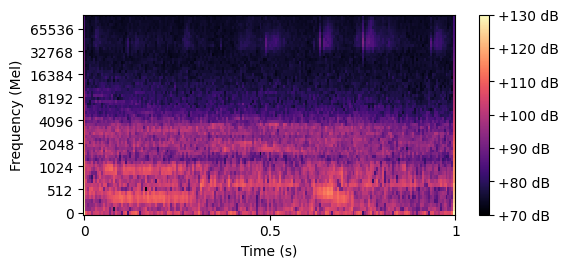

119/133
197.0
evaluation_v2
15173    5725.200801150830.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200801_15114700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


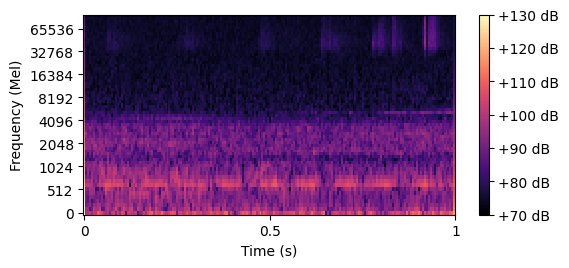

120/133
nan
irene_20min
15950    NaN
Name: labeled_snippet_filename, dtype: str
KAM_20210727_18265981.wav
ECHO: true 0 vs pred 0   HFPC: true 1 vs pred 1   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


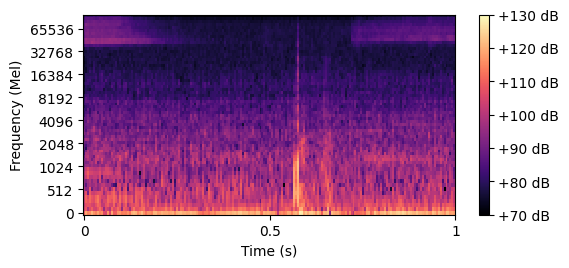

121/133
nan
irene_5min
16567    NaN
Name: labeled_snippet_filename, dtype: str
RDL_20200730_08453584.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


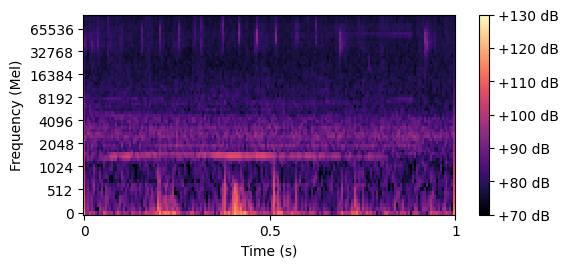

122/133
nan
irene_20min
10000    NaN
Name: labeled_snippet_filename, dtype: str
CAC_20210714_11571700.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


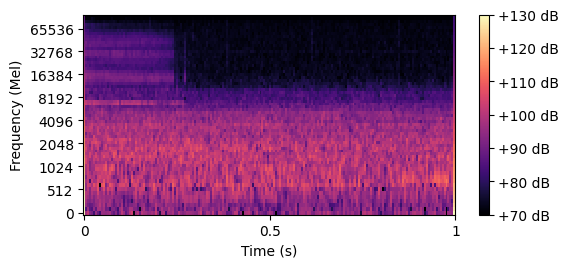

123/133
115.0
evaluation_v2
13948    5725.200730122420.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200730_12261500.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


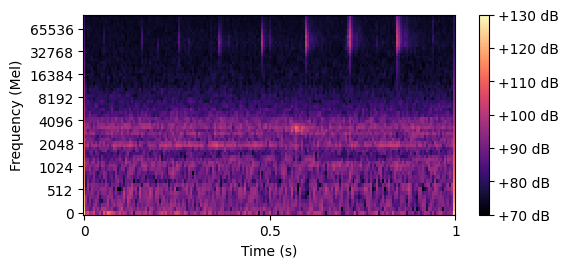

124/133
12.0
evaluation_v2
14356    5725.200731140339.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200731_14035100.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


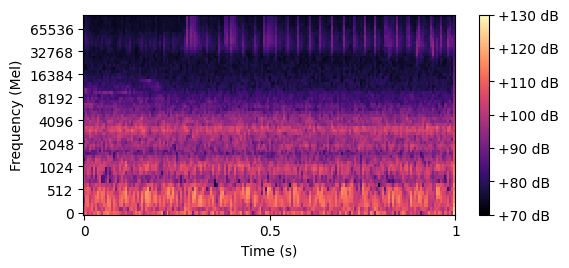

125/133
15.0
evaluation_v2
14359    5725.200731140339.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200731_14035400.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


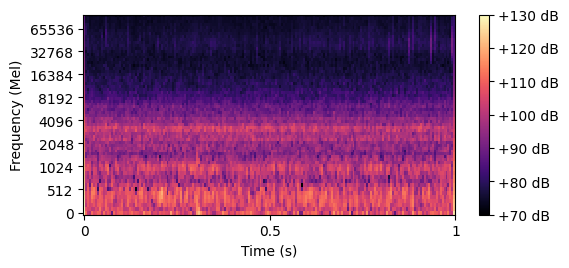

126/133
36.0
evaluation_v2
15211    5725.200801152155.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200801_15214100.wav
ECHO: true 0 vs pred 0   HFPC: true 1 vs pred 0   BBPC: true 1 vs pred 0   Whistle: true 1 vs pred 0


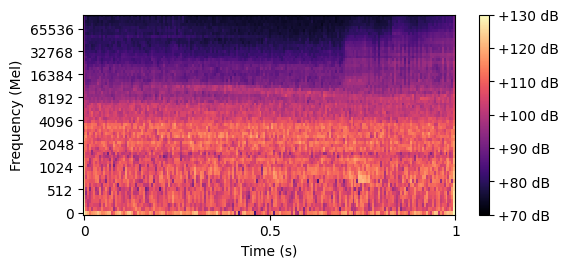

127/133
37.0
evaluation_v2
15212    5725.200801152155.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200801_15214200.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


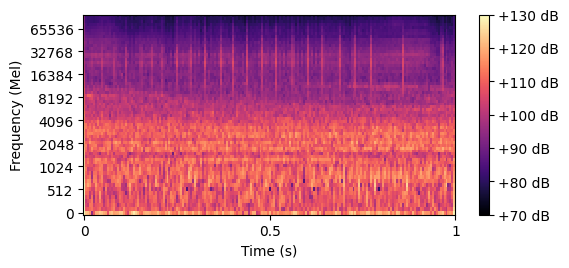

128/133
38.0
evaluation_v2
15213    5725.200801152155.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200801_15214300.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


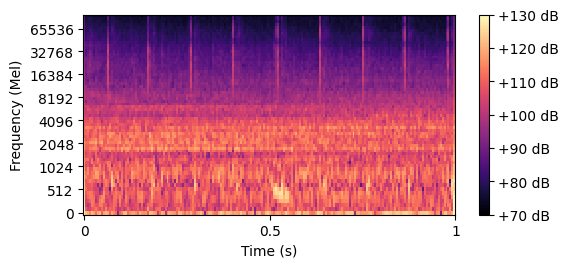

129/133
57.0
evaluation_v2
15232    5725.200801152155.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200801_15220200.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 1   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


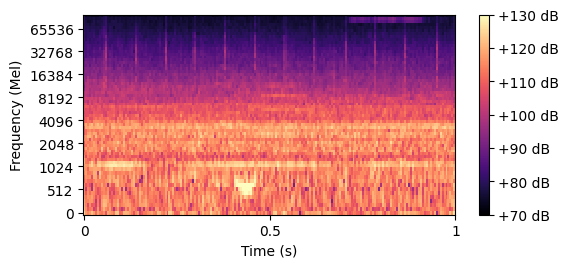

130/133
65.0
evaluation_v2
15240    5725.200801152155.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200801_15221000.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


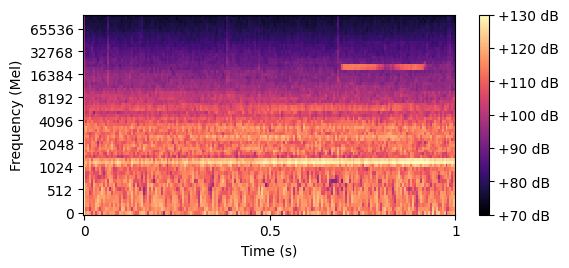

131/133
67.0
evaluation_v2
15242    5725.200801152155.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200801_15221200.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


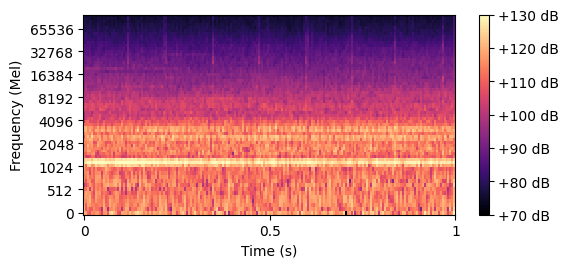

132/133
nan
irene_20min
15726    NaN
Name: labeled_snippet_filename, dtype: str
KAM_20210720_14424383.wav
ECHO: true 0 vs pred 0   HFPC: true 1 vs pred 1   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


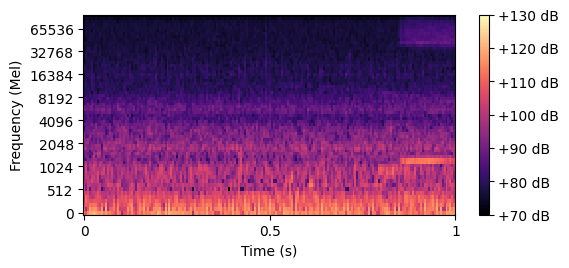

In [63]:

DATA_DIRECTORY = "../../data/"

wavs_folder = DATA_DIRECTORY + "Verified_Dataset/clip_wavs/"

# sample = labels_df[labels_df["Notes"].notna()]
# sample = labels_df[labels_df["clip_filename"] == "CAC_20210714_08342600.wav"]
# boat_df = test_predictions_df[test_predictions_df["Boat"] == 1]
# sample = boat_df[boat_df["Whistle_correct"] == False].sample(30)

# sample = test_predictions_df[(test_predictions_df["labeled_snippet_filename"] == "5725.200726191905.snippet.wav")& (test_predictions_df["Whistle"] == 1)].sample(10)
sample = test_predictions_df[(test_predictions_df["Boat"] == 1)& (test_predictions_df["Whistle_correct"] == False) & (test_predictions_df["Whistle_true"] == 1)]

# sample = test_predictions_df[test_predictions_df["Filename"] == "RDL_20200727_13012408.pt"]
count=0
for index, row in sample.iterrows():  
    print(f"{count}/{len(sample)}")
    count+=1
    print(row["Begin Time (s)"])
    wav_filename = row["Filename"].replace(".pt", ".wav")
    print(row["labeling_effort"])
    # print(row["anotator"])
    print(labels_df[labels_df["clip_filename"] ==wav_filename]["labeled_snippet_filename"])  
    
    title = f"{wav_filename}\n"

    for label in ["ECHO", "HFPC", "BBPC", "Whistle"]:
        true_val = row[f"{label}_true"] if f"{label}_true" in row else row.get(label, None)
        pred_val = row[f"{label}_pred"] if f"{label}_pred" in row else None
        title += f"{label}: true {int(true_val)} vs pred {int(pred_val)}   "
    title = title.strip()
    print(title)
    # print("Boat:", row["Boat"])

    file_path = wavs_folder + wav_filename

    audio, sr, original_sr = spect_generator.load_audio(file_path)


    power_spect = spect_generator.compute_mel_power_spect(audio)

    
    dB_spect = spect_generator.power_to_db(power_spect, hydrophone_sensitivity=row["HydrophoneSensitivity"])
  

    spect_generator.plot_spect(dB_spect, figsize=(6,2.6), title="", tick_interval=0.5, colorbar_range=(70, 130), transparent_background=True)

    # dB_spect_normalized = spect_generator.min_max_normalization(dB_spect)
    
    # dB_spect_resized = spect_generator.resize_spect(dB_spect_normalized, img_shape=(244,244))

    